# Installing all libraries

In [ ]:
import requests
from bs4 import BeautifulSoup
from datetime import datetime
import time
import json
import os
import pandas as pd
import torch
from transformers import BertTokenizer, BertModel
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from google.colab import drive
import yfinance as yf

!pip install nltk pandas
import nltk
nltk.download('punkt')       # Pour la tokenisation
nltk.download('wordnet')    # Pour la lemmatisation
nltk.download('stopwords')  # Pour les stopwords

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Mounting the google drive

Also creating the path were tweets are saved

In [ ]:
drive.mount('/content/drive')

# Chemin vers votre dossier
#base_path = "/content/drive/MyDrive/M2Economiedudévleoppement/Text analysis/Poster"
base_path = "/content/drive/MyDrive/Poster"

import json
import pandas as pd
from datetime import datetime
import os

nltk.download('stopwords')

# Load tweets from Drive
save_path_tweets = os.path.join(base_path, "trump_tweets.json")
with open(save_path_tweets, "r", encoding="utf-8") as f:
    tweets = json.load(f)

print(f"✅ {len(tweets)} tweets loaded")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ 16492 tweets loaded


Here we load the tweets ran in code **modifiable version message + date**

In [ ]:
# Monter Google Drive
drive.mount('/content/drive')

# Chemins vers les fichiers sauvegardés
#base_path = "/content/drive/MyDrive/M2Economiedudévleoppement/Text analysis/Poster"
base_path = "/content/drive/MyDrive/Poster"
save_path_tweets = f"{base_path}/trump_tweets.json"
save_path_embeddings = f"{base_path}/trump_tweets_embeddings.pt"

# Charger les tweets
with open(save_path_tweets, "r", encoding="utf-8") as f:
    loaded_tweets = json.load(f)
print("Tweets chargés avec succès !")
print(f"Nombre de tweets chargés : {len(loaded_tweets)}")

# Charger les embeddings
loaded_embeddings = torch.load(save_path_embeddings)
print("Embeddings chargés avec succès !")
print(f"Forme des embeddings : {loaded_embeddings.shape}")

# Afficher un exemple de tweet et son embedding correspondant (si les indices correspondent)
if len(loaded_tweets) > 0 and len(loaded_embeddings) > 0:
    print("\nExemple de tweet et son embedding :")
    print(f"Tweet : {loaded_tweets[0]}")
    print(f"Embedding associé : {loaded_embeddings[0]}")

#Save sur le drive
torch.save(loaded_embeddings, f"{base_path}/trump_tweets_embeddings.pt")
print("💾 Embeddings sauvegardés sur Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tweets chargés avec succès !
Nombre de tweets chargés : 16492
Embeddings chargés avec succès !


AttributeError: 'list' object has no attribute 'shape'

#Pre-processing

In [ ]:
import re
import spacy
from nltk.corpus import stopwords

nlp = spacy.load("en_core_web_sm")

# Load tweets
save_path_tweets = os.path.join(base_path, "trump_tweets.json")
with open(save_path_tweets, "r", encoding="utf-8") as f:
    tweets = json.load(f)

print(f"✅ {len(tweets)} tweets loaded")

# Stopwords setup
STOPWORDS = set(stopwords.words("english"))
KEEP_WORDS = {"not", "no", "never", "against", "up", "down"}
#Keep always? yes?
STOPWORDS -= KEEP_WORDS

def preprocess(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs, mentions, hashtags, punctuation
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"'s\b", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    # 3. Lemmatization + stopword removal via spaCy
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if token.lemma_ not in STOPWORDS
        and len(token.lemma_) > 2
        and not token.is_space
    ]
    return " ".join(tokens)

# Apply preprocessing
for tweet in tweets:
    tweet["text_clean"] = preprocess(tweet["text"]) if tweet["text"] else ""

# Verification
for tweet in tweets[:3]:
    print(f"ORIGINAL : {tweet['text'][:100]}")
    print(f"CLEAN    : {tweet['text_clean'][:100]}")
    print()

# Save preprocessed file to Drive
save_path_preprocessed = os.path.join(base_path, "trump_tweets_preprocessed.json")
with open(save_path_preprocessed, "w", encoding="utf-8") as f:
    json.dump(tweets, f, ensure_ascii=False, indent=2)
print(f"💾 Saved to {save_path_preprocessed}")

tweets_clean = [t for t in tweets if t["text_clean"].strip() != ""]
print(f"✅ {len(tweets_clean)} non-empty tweets out of {len(tweets)} total")
print(f"🗑️ {len(tweets) - len(tweets_clean)} empty tweets removed (retweets without text)")

# Create DataFrame
df = pd.DataFrame(tweets_clean)
print(f"\n📊 DataFrame shape: {df.shape}")
print(df[["date", "time_et", "text", "text_clean"]].head())

✅ 16492 tweets loaded
ORIGINAL : News Conference today, prior to Trump Kennedy Center Board Meeting. Thank you!
CLEAN    : news conference today prior trump kennedy center board meeting thank

ORIGINAL : The crazed Democrats are not allowing TSA Agents to get paid. The deal was made a long time ago. The
CLEAN    : craze democrat not allow tsa agent get pay deal make long time ago break order get money sanctuary c

ORIGINAL : Michael Whatley is so Great! Running against a really bad former Governor who set murderers free to 
CLEAN    : michael whatley great run against really bad former governor set murderer free kill grossly incompet

💾 Saved to /content/drive/MyDrive/Poster/trump_tweets_preprocessed.json
✅ 11863 non-empty tweets out of 16492 total
🗑️ 4629 empty tweets removed (retweets without text)

📊 DataFrame shape: (11863, 6)
         date   time_et                                               text  \
0  2026-03-16  09:19:11  News Conference today, prior to Trump Kennedy ...   
1

#Changer place

In [ ]:
# Fonction pour extraire et convertir l'horodatage
def parse_datetime(datetime_str):
    # The format string needs to match the input string exactly
    return datetime.strptime(datetime_str, "%Y-%m-%dT%H:%M:%S%z")

# Appliquer la fonction pour créer une colonne 'datetime'
df['datetime'] = df['datetime_full'].apply(parse_datetime)

print(df[['datetime_full', 'datetime']].head())

# Afficher les premières lignes du DataFrame
print(df.head())

# Afficher les types de données
print(df.dtypes)


               datetime_full                   datetime
0  2026-03-16T09:19:11-04:00  2026-03-16 09:19:11-04:00
1  2026-03-16T09:16:38-04:00  2026-03-16 09:16:38-04:00
2  2026-03-16T07:50:09-04:00  2026-03-16 07:50:09-04:00
3  2026-03-15T22:46:08-04:00  2026-03-15 22:46:08-04:00
4  2026-03-15T22:45:37-04:00  2026-03-15 22:45:37-04:00
         date   time_et              datetime_full url  \
0  2026-03-16  09:19:11  2026-03-16T09:19:11-04:00       
1  2026-03-16  09:16:38  2026-03-16T09:16:38-04:00       
2  2026-03-16  07:50:09  2026-03-16T07:50:09-04:00       
3  2026-03-15  22:46:08  2026-03-15T22:46:08-04:00       
4  2026-03-15  22:45:37  2026-03-15T22:45:37-04:00       

                                                text  \
0  News Conference today, prior to Trump Kennedy ...   
1  The crazed Democrats are not allowing TSA Agen...   
2  Michael Whatley is so Great! Running against a...   
3  RT: https://truthsocial.com/users/realDonaldTr...   
4  The decision that mattered most 

#LSA/SVD -> REPLACE BY LDA (better)

We do a Singular Value Decomposition with LSA, a topic modeling technique, which reduces dimensionality by capturing the themes in 20 components, for instance:

* Trade/Tariffs/China
* Legal/Courts
* Geopolitics/Russia
* Economy/Inflation


*I think it's complementary to BERT but I am not sure*

*BERT is a more sophisticated model which allows to classify as: negative, neutral, positive*

In [ ]:
# TF-IDF + SVD (LSA)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import numpy as np

# Extract cleaned texts
texts = [t["text_clean"] for t in tweets_clean]

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(texts)
print(f"✅ TF-IDF matrix: {tfidf_matrix.shape}")

# SVD — 20 latent components
n_components = 20
svd = TruncatedSVD(n_components=n_components, random_state=42)
lsa_matrix = svd.fit_transform(tfidf_matrix)

# Explained variance
explained = svd.explained_variance_ratio_
print(f"\n📊 Explained variance per component:")
for i, var in enumerate(explained):
    print(f"  Component {i+1:02d} : {var:.3f} ({var*100:.1f}%)")
print(f"\n  Cumulative total: {explained.sum()*100:.1f}%")

✅ TF-IDF matrix: (11863, 5000)

📊 Explained variance per component:
  Component 01 : 0.007 (0.7%)
  Component 02 : 0.012 (1.2%)
  Component 03 : 0.011 (1.1%)
  Component 04 : 0.010 (1.0%)
  Component 05 : 0.008 (0.8%)
  Component 06 : 0.006 (0.6%)
  Component 07 : 0.005 (0.5%)
  Component 08 : 0.005 (0.5%)
  Component 09 : 0.005 (0.5%)
  Component 10 : 0.004 (0.4%)
  Component 11 : 0.004 (0.4%)
  Component 12 : 0.004 (0.4%)
  Component 13 : 0.004 (0.4%)
  Component 14 : 0.003 (0.3%)
  Component 15 : 0.003 (0.3%)
  Component 16 : 0.003 (0.3%)
  Component 17 : 0.003 (0.3%)
  Component 18 : 0.003 (0.3%)
  Component 19 : 0.003 (0.3%)
  Component 20 : 0.003 (0.3%)

  Cumulative total: 10.6%


#Inspect themes

Here are the 20 themes that the LSA extracted from the tweets.
We can see that our matrix was substansially reduced: 11863x20
20: for 20 components

In [ ]:
terms = vectorizer.get_feature_names_out()

print("🔍 Top 10 words per latent component:\n")
for i, comp in enumerate(svd.components_):
    top_indices = comp.argsort()[-10:][::-1]
    top_words = [terms[j] for j in top_indices]
    print(f"Component {i+1:02d} : {', '.join(top_words)}")

lsa_filtered = lsa_matrix
print(f"✅ Complete LSA matrix: {lsa_filtered.shape}")

🔍 Top 10 words per latent component:

Component 01 : great, america, make, not, trump, president, country, thank, border, people
Component 02 : trump, thank, president, not, biden, donald, joe, live, get, new
Component 03 : great, america, thank, make, honor, together, youmaga, pennsylvania, djt, safe
Component 04 : thank, secure, endorsement, congressional, honor, complete, border, youmaga, second, total
Component 05 : trump, live, join, donald, among, president, see, eastern, soonmaga, watch
Component 06 : biden, joe, crooked, president, kamala, trump, america, harris, border, democracy
Component 07 : interference, election, biden, joe, live, join, new, crooked, york, judge
Component 08 : trump, president, interference, election, judge, case, york, new, america, trial
Component 09 : kamala, harris, election, trump, interference, vote, comrade, day, win, america
Component 10 : new, york, kamala, judge, harris, case, trump, hampshire, biden, joe
Component 11 : vote, win, get, big, new,

#VADER - Sentiment dictionnary

VADER is designed to analyse social media text and informal texting. VADER analyses the polarity of words and assigning a sentiment score to each word based on its emotional value. These individual word scores are then combined to calculate an overall sentiment score for the entire text. https://www.geeksforgeeks.org/python/python-sentiment-analysis-using-vader/

Compound score between -1 and +1.
* > 0.05: Positive sentiment
* < -0.05: Negative sentiment
* Between -0.05 and 0.05: Neutral sentiment


In [ ]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Calculate VADER scores and add them to each tweet in tweets_clean
for tweet in tweets_clean:
    # We use the original text, not the cleaned text, as VADER is designed for natural language (with punctuation)
    scores = analyzer.polarity_scores(tweet["text"])
    tweet["vader_neg"]     = scores["neg"]
    tweet["vader_neu"]     = scores["neu"]
    tweet["vader_pos"]     = scores["pos"]
    tweet["vader_compound"] = scores["compound"]

def sentiment_scores(sentence):
    sentiment_dict = analyzer.polarity_scores(sentence)

    print(f"Sentiment Scores: {sentiment_dict}")
    print(f"Negative Sentiment: {sentiment_dict['neg']*100}%")
    print(f"Neutral Sentiment: {sentiment_dict['neu']*100}%")
    print(f"Positive Sentiment: {sentiment_dict['pos']*100}%")

    if sentiment_dict['compound'] >= 0.05:
        print("Overall Sentiment: Positive")
    elif sentiment_dict['compound'] <= -0.05:
        print("Overall Sentiment: Negative")
    else:
        print("Overall Sentiment: Neutral")


# Check
print("🔍 VADER examples:\n")
for tweet in tweets_clean[:5]:
    print(f"  [{tweet['date']} {tweet['time_et']}]")
    print(f"  💬 {tweet['text'][:100]}")
    print(f"  📊 compound={tweet['vader_compound']:.3f} | pos={tweet['vader_pos']:.3f} | neg={tweet['vader_neg']:.3f}")
    sentiment_scores(tweet["text"])
    print()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.5 MB/s eta 0:00:00
🔍 VADER examples:

  [2026-03-16 09:19:11]
  💬 News Conference today, prior to Trump Kennedy Center Board Meeting. Thank you!
  📊 compound=0.420 | pos=0.202 | neg=0.000
Sentiment Scores: {'neg': 0.0, 'neu': 0.798, 'pos': 0.202, 'compound': 0.4199}
Negative Sentiment: 0.0%
Neutral Sentiment: 79.80000000000001%
Positive Sentiment: 20.200000000000003%
Overall Sentiment: Positive

  [2026-03-16 09:16:38]
  💬 The crazed Democrats are not allowing TSA Agents to get paid. The deal was made a long time ago. The
  📊 compound=-0.938 | pos=0.000 | neg=0.274
Sentiment Scores: {'neg': 0.274, 'neu': 0.726, 'pos': 0.0, 'compound': -0.938}
Negative Sentiment: 27.400000000000002%
Neutral Sentiment: 72.6%
Positive Sentiment: 0.0%
Overall Sentiment: Negative

  [2026-03-16 07:50:09]
  💬 Michael Whatley is so Great! Running against a really bad former Governor who set murderers free to 
  📊 compound=0.839 | pos=0.242 | neg=0.1

Old code for VADER

# Zero shot BERT classification

2 methods exist:
* **K-Means on embeddings BERT** (3 clusters): Let the algorithm automatically group the tweets into 3 clusters, then manually label each cluster as "Risk," "Neutral," or "Optimistic".

* **Zero-shot classification:**
You use a pre-trained model that classifies directly without additional training. *=> Recommended by Clement*

## Difference with VADER
* ***VADER**: Is it positive, negative, neutral?*

* ***Zero-shot BERT**: What type of message is it? (risk, optim, neu?)*

* *VADER may misinterpret the political or financial context because it analyzes text word by word. BERT understands the entire sentence.*

* *By combining the two in the rhetoric index, we capture both the emotional tone (VADER) and the semantic content (BERT).*

#SUPPRIMER LES RETWEETS, PEUT-ÊTRE PARTIR DE LA BASE NETTOYEE!

We add precise labels and related it to financial markets as the zero-shot classificaiton takes into account the description of the labels to classify. That way, we do not need to filter out the tweets that are not related to economics and politics.
```
candidate_labels = [
    "this message creates market uncertainty or fear",
    "this message is neutral or unrelated to markets",
    "this message is reassuring or positive for markets"]
```


In [ ]:
# Filter tweets
tweets_to_classify = [
    t for t in tweets_clean
    if len(t["text"].split()) > 5
    and not t["text"].startswith("RT:")
]
print(f"✅ {len(tweets_to_classify)} tweets to classify")

# Zero-shot classification
from transformers import pipeline
from collections import Counter

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if torch.cuda.is_available() else -1
)

candidate_labels = [
    "this message creates market uncertainty or fear",
    "this message is neutral or unrelated to markets",
    "this message is reassuring or positive for markets"
]

label_map = {
    "this message creates market uncertainty or fear": "Uncertainty",
    "this message is neutral or unrelated to markets": "Neutral",
    "this message is reassuring or positive for markets": "Optimistic"
}

print(f"🔄 Classifying {len(tweets_to_classify)} tweets...")

for i, tweet in enumerate(tweets_to_classify):
    result = classifier(tweet["text"], candidate_labels)
    tweet["bert_label"] = label_map[result["labels"][0]]
    tweet["bert_score"] = round(result["scores"][0], 4)
    if i % 500 == 0:
        print(f"  {i}/{len(tweets_to_classify)} processed...")

# Distribution
labels = [t["bert_label"] for t in tweets_to_classify]
dist = Counter(labels)
print(f"\n📊 Label distribution:")
for label, count in dist.items():
    print(f"  {label}: {count} ({count/len(labels)*100:.1f}%)")

# Exemples
print("\n🔍 Examples:\n")
for tweet in tweets_to_classify[:5]:
    print(f"  💬 {tweet['text'][:80]}")
    print(f"  🏷️  {tweet['bert_label']} (confidence: {tweet['bert_score']:.3f})")
    print()

# Sauvegarder
save_path = os.path.join(base_path, "trump_tweets_classified.json")
with open(save_path, "w", encoding="utf-8") as f:
    json.dump(tweets_to_classify, f, ensure_ascii=False, indent=2)
print(f"💾 Saved to {save_path}")

✅ 10415 tweets to classify


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

🔄 Classifying 10415 tweets...
  0/10415 processed...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  500/10415 processed...
  1000/10415 processed...
  1500/10415 processed...
  2000/10415 processed...
  2500/10415 processed...
  3000/10415 processed...
  3500/10415 processed...
  4000/10415 processed...
  4500/10415 processed...
  5000/10415 processed...
  5500/10415 processed...
  6000/10415 processed...
  6500/10415 processed...
  7000/10415 processed...
  7500/10415 processed...
  8000/10415 processed...
  8500/10415 processed...
  9000/10415 processed...
  9500/10415 processed...
  10000/10415 processed...

📊 Label distribution:
  Optimistic: 5371 (51.6%)
  Uncertainty: 4823 (46.3%)
  Neutral: 221 (2.1%)

🔍 Examples:

  💬 News Conference today, prior to Trump Kennedy Center Board Meeting. Thank you!
  🏷️  Optimistic (confidence: 0.419)

  💬 The crazed Democrats are not allowing TSA Agents to get paid. The deal was made 
  🏷️  Uncertainty (confidence: 0.785)

  💬 Michael Whatley is so Great! Running against a really bad former Governor who se
  🏷️  Optimistic (confidence: 0.556)

In [ ]:
# Nouveaux labels plus naturels
candidate_labels = ["positive and optimistic", "negative and threatening", "neutral and informational"]

for i, tweet in enumerate(tweets_to_classify):
    result = classifier(tweet["text"], candidate_labels)

    # Mapper vers Risk/Neutral/Optimistic
    label_map = {
        "positive and optimistic": "Optimistic",
        "negative and threatening": "Risk",
        "neutral and informational": "Neutral"
    }
    tweet["bert_label"] = label_map[result["labels"][0]]
    tweet["bert_score"] = round(result["scores"][0], 4)
    if i % 500 == 0:
        print(f"  {i}/{len(tweets_to_classify)} processed...")

# Distribution
labels = [t["bert_label"] for t in tweets_to_classify]
dist = Counter(labels)
print(f"\n📊 Label distribution:")
for label, count in dist.items():
    print(f"  {label}: {count} ({count/len(labels)*100:.1f}%)")

  0/10415 processed...


KeyboardInterrupt: 

#Word cloud

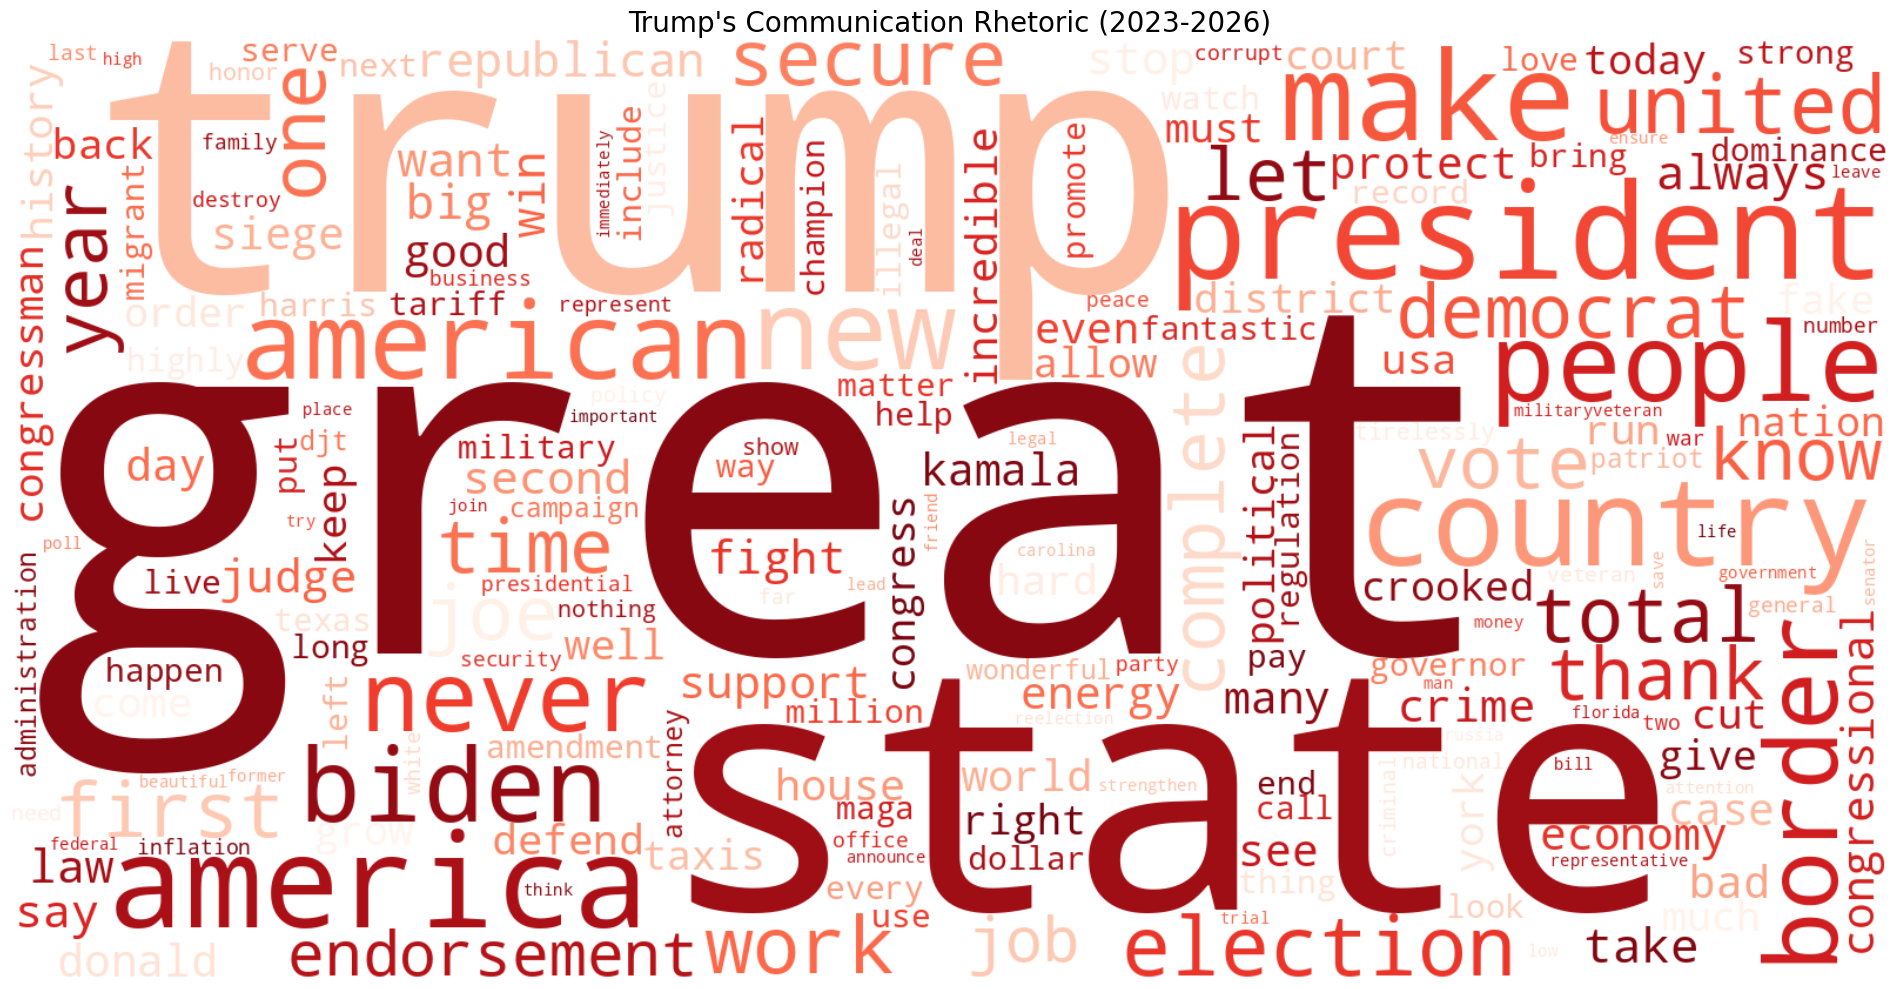

💾 Saved to wordcloud_trump.png


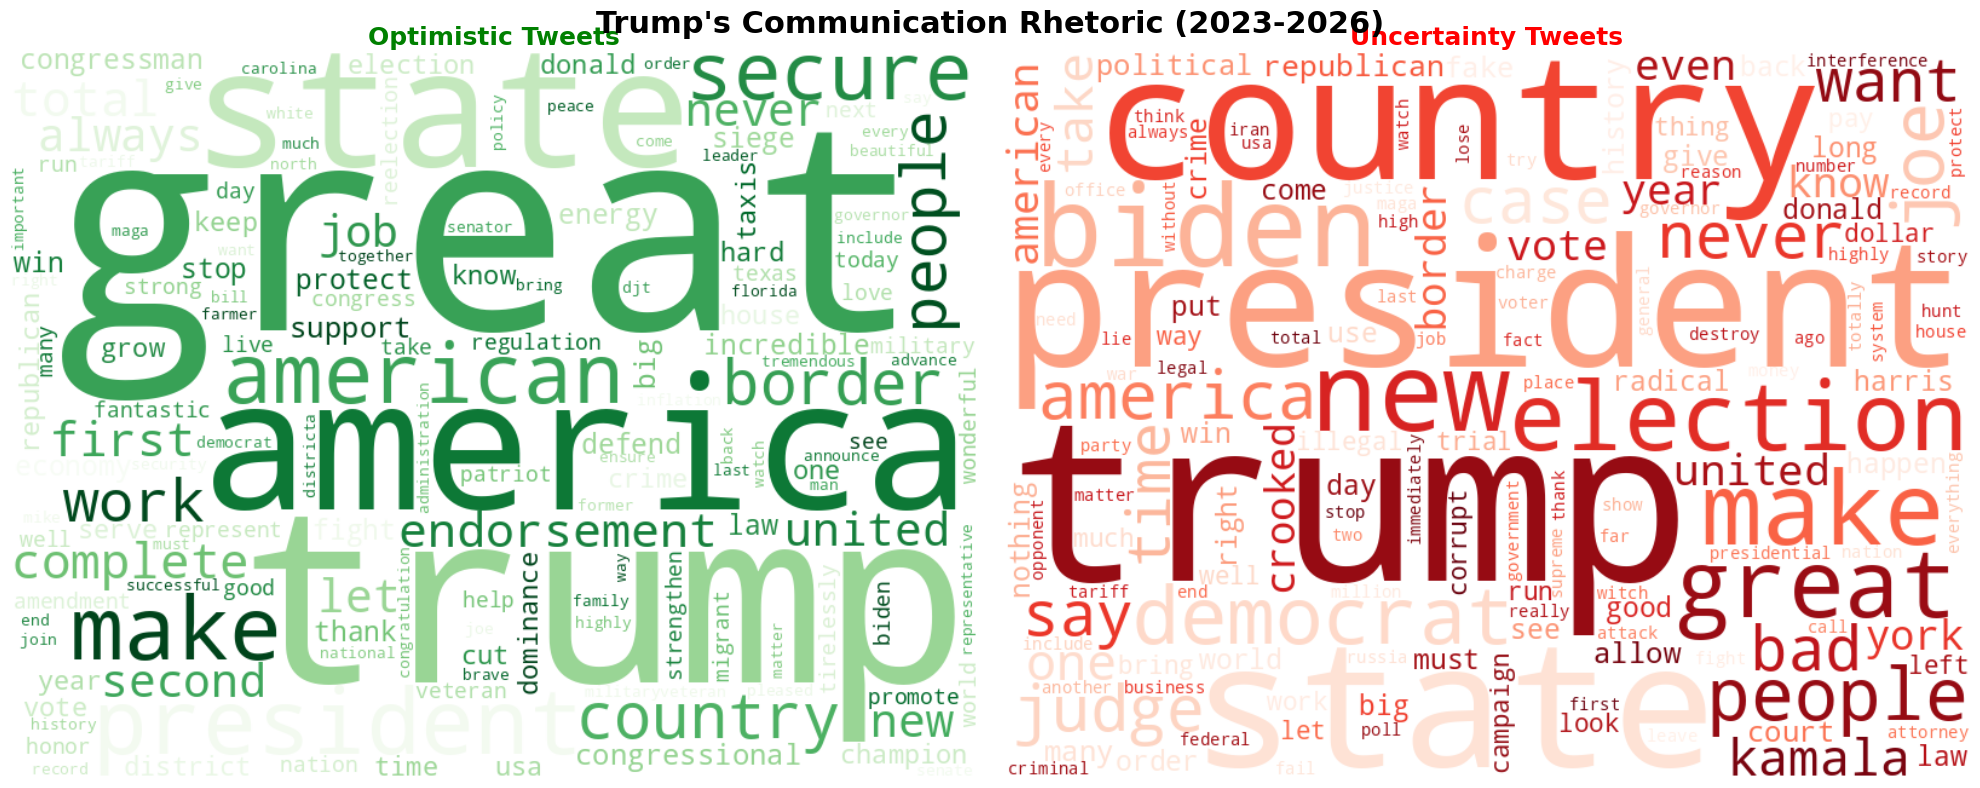

💾 Saved


In [ ]:
!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

#General

# Concatener tous les textes nettoyés
all_text = " ".join([t["text_clean"] for t in tweets_clean])

# Générer le word cloud
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    max_words=200,
    colormap="Reds",
    collocations=False
).generate(all_text)

# Afficher
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Trump's Communication Rhetoric (2023-2026)", fontsize=20)
plt.tight_layout()
plt.savefig("wordcloud_trump.png", dpi=300, bbox_inches="tight")
plt.show()
print("💾 Saved to wordcloud_trump.png")

#Word cloud by label, using zero-shot classification

# Textes par label
text_optimistic = " ".join([t["text_clean"] for t in tweets_to_classify
                            if t["bert_label"] == "Optimistic"])
text_uncertainty = " ".join([t["text_clean"] for t in tweets_to_classify
                             if t["bert_label"] == "Uncertainty"])

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Word cloud Optimistic
wc_optimistic = WordCloud(width=800, height=600, background_color="white",
                          max_words=150, colormap="Greens",
                          collocations=False).generate(text_optimistic)
axes[0].imshow(wc_optimistic, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Optimistic Tweets", fontsize=18, fontweight="bold", color="green")

# Word cloud Uncertainty
wc_uncertainty = WordCloud(width=800, height=600, background_color="white",
                           max_words=150, colormap="Reds",
                           collocations=False).generate(text_uncertainty)
axes[1].imshow(wc_uncertainty, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Uncertainty Tweets", fontsize=18, fontweight="bold", color="red")

plt.suptitle("Trump's Communication Rhetoric (2023-2026)", fontsize=22, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(base_path, "wordcloud_sentiment.png"), dpi=300, bbox_inches="tight")
plt.show()
print("💾 Saved")


#Prediction



##Import VIX

In [ ]:
# Télécharger les données journalières (Daily)
vix_data = yf.download("^VIX", start="2023-11-01", interval="1d")

print(vix_data.head())

/tmp/ipykernel_2969/3726773255.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_data = yf.download("^VIX", start="2023-11-01", interval="1d")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low   Open Volume
Ticker           ^VIX       ^VIX       ^VIX   ^VIX   ^VIX
Date                                                     
2023-11-01  16.870001  18.420000  16.629999  18.02      0
2023-11-02  15.660000  16.620001  15.580000  16.59      0
2023-11-03  14.910000  15.830000  14.910000  15.70      0
2023-11-06  14.890000  15.580000  14.840000  15.39      0
2023-11-07  14.810000  15.170000  14.710000  15.10      0


associer chaque tweet à sa valeur VIX correspondante

tweets ont un décalage de -04:00 (Heure de New York / ET), tandis que tes données VIX Yahoo Finance étaient en +00:00 (UTC).

* Even though the VIX fluctuates throughout the day, we only have access to the opening and closing values. We therefore treat the VIX as daily data

* We ensure that tweets published after 4pm ET (Eastern Time, US market closing time) are matched with the next-day closing VIX, while tweets published before 4pm ET are matched with the same-day closing VIX.

* For tweets published during the week-end, we assigned the last known VIX


In [ ]:
# Vérifier le timezone des tweets
print("Exemples de datetime_full :")
for tweet in tweets_clean[:5]:
    print(f"  {tweet['datetime_full']}")

# Vérifier le timezone de yfinance
print("Timezone VIX yfinance :")
print(vix_data.index.tz)
print(vix_data.head())

Exemples de datetime_full :
  2026-03-16T09:19:11-04:00
  2026-03-16T09:16:38-04:00
  2026-03-16T07:50:09-04:00
  2026-03-15T22:46:08-04:00
  2026-03-15T22:45:37-04:00
Timezone VIX yfinance :
None
Price           Close       High        Low   Open Volume
Ticker           ^VIX       ^VIX       ^VIX   ^VIX   ^VIX
Date                                                     
2023-11-01  16.870001  18.420000  16.629999  18.02      0
2023-11-02  15.660000  16.620001  15.580000  16.59      0
2023-11-03  14.910000  15.830000  14.910000  15.70      0
2023-11-06  14.890000  15.580000  14.840000  15.39      0
2023-11-07  14.810000  15.170000  14.710000  15.10      0


In [ ]:
import yfinance as yf
import pandas as pd

# Télécharger le VIX
vix_data = yf.download("^VIX", start="2023-11-05", interval="1d")
temp_vix_data = vix_data.reset_index()
temp_vix_data.columns = ['_'.join(str(s) for s in col if s).strip() if isinstance(col, tuple) else col for col in temp_vix_data.columns]
filtered_vix_data = temp_vix_data.rename(columns={'Close_^VIX': 'vix', 'Date': 'vix_date'})
filtered_vix_data["vix_date"] = pd.to_datetime(filtered_vix_data["vix_date"]).dt.date
filtered_vix_data = filtered_vix_data[["vix_date", "vix"]]

# Règle avant/après 16h ET
def assign_vix_date(row):
    if row["time_et"] > "16:00:00":
        return (pd.to_datetime(row["date"]) + pd.Timedelta(days=1)).date()
    else:
        return pd.to_datetime(row["date"]).date()

df["vix_date"] = df.apply(assign_vix_date, axis=1)

# Merge sur vix_date
if 'vix' in df.columns:
    df = df.drop(columns=['vix'], errors='ignore')

df_final = df.merge(filtered_vix_data, on="vix_date", how="left")

# ffill pour les weekends/jours fériés
df_final = df_final.sort_values("vix_date")
df_final["vix"] = df_final["vix"].ffill()

# 8. Vérification du résultat
print("Matching terminé :")
print(df_final[['datetime', 'text', 'vix']].head(10))

/tmp/ipykernel_2969/3928576054.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_data = yf.download("^VIX", start="2023-11-05", interval="1d")
[*********************100%***********************]  1 of 1 completed


Matching terminé :
                        datetime  \
11862  2023-11-05 09:22:16-05:00   
11854  2023-11-05 15:18:12-05:00   
11855  2023-11-05 14:39:42-05:00   
11856  2023-11-05 14:10:28-05:00   
11861  2023-11-05 12:49:46-05:00   
11858  2023-11-05 13:57:41-05:00   
11859  2023-11-05 13:55:26-05:00   
11860  2023-11-05 12:58:12-05:00   
11857  2023-11-05 14:00:19-05:00   
11836  2023-11-06 13:45:54-05:00   

                                                    text    vix  
11862  Sloppy Chris & “Aida” got booed off the stage ...    NaN  
11854  Kim Reynolds told me that she was going to rem...    NaN  
11855  If and when Kim Reynolds of Iowa endorses Ron ...    NaN  
11856  RT@marklevinshowNotice NOT ONE WORD from the D...    NaN  
11861  This is just a “tiny” part of what’s happening...    NaN  
11858  RT@catturd2Back to reality ... Every DeSantis ...    NaN  
11859  That’s because people don’t like disloyalty! I...    NaN  
11860  Join me for a TRUMP RALLY this Wednesday, Nove...

Checking if the matching was correctly done (don't necessarily have to run it)

In [ ]:
# Vérification (jours ouvrés)
sample = df_final[df_final["date"].between("2023-11-08", "2023-11-10")]
print(sample[["date", "time_et", "vix_date", "vix"]].to_string())

# Vérifier les tweets après 16h ET
sample_after = df_final[df_final["time_et"] > "16:00:00"][["date", "time_et", "vix_date", "vix"]].head(10)
print("Tweets après 16h ET :")
print(sample_after.to_string())

# Vérifier que vix_date = date + 1 jour
print("\nVérification date + 1 :")
for _, row in sample_after.iterrows():
    expected = (pd.to_datetime(row["date"]) + pd.Timedelta(days=1)).date()
    match = row["vix_date"] == expected
    print(f"  {row['date']} {row['time_et']} → vix_date={row['vix_date']} (attendu={expected}) {'✅' if match else '❌'}")

             date   time_et    vix_date    vix
11812  2023-11-08  12:30:09  2023-11-08  14.45
11807  2023-11-08  15:17:18  2023-11-08  14.45
11809  2023-11-08  14:41:23  2023-11-08  14.45
11810  2023-11-08  13:58:12  2023-11-08  14.45
11811  2023-11-08  12:43:28  2023-11-08  14.45
11813  2023-11-08  11:16:22  2023-11-08  14.45
11808  2023-11-08  14:42:16  2023-11-08  14.45
11815  2023-11-08  09:25:50  2023-11-08  14.45
11816  2023-11-08  09:25:38  2023-11-08  14.45
11817  2023-11-08  09:25:24  2023-11-08  14.45
11818  2023-11-08  01:17:51  2023-11-08  14.45
11820  2023-11-08  00:15:49  2023-11-08  14.45
11819  2023-11-08  00:16:59  2023-11-08  14.45
11814  2023-11-08  09:59:12  2023-11-08  14.45
11789  2023-11-09  00:56:01  2023-11-09  15.29
11788  2023-11-09  00:58:40  2023-11-09  15.29
11787  2023-11-09  01:00:35  2023-11-09  15.29
11785  2023-11-09  08:54:12  2023-11-09  15.29
11784  2023-11-09  09:18:21  2023-11-09  15.29
11781  2023-11-09  09:20:53  2023-11-09  15.29
11782  2023-1

#Sentiment trends over time

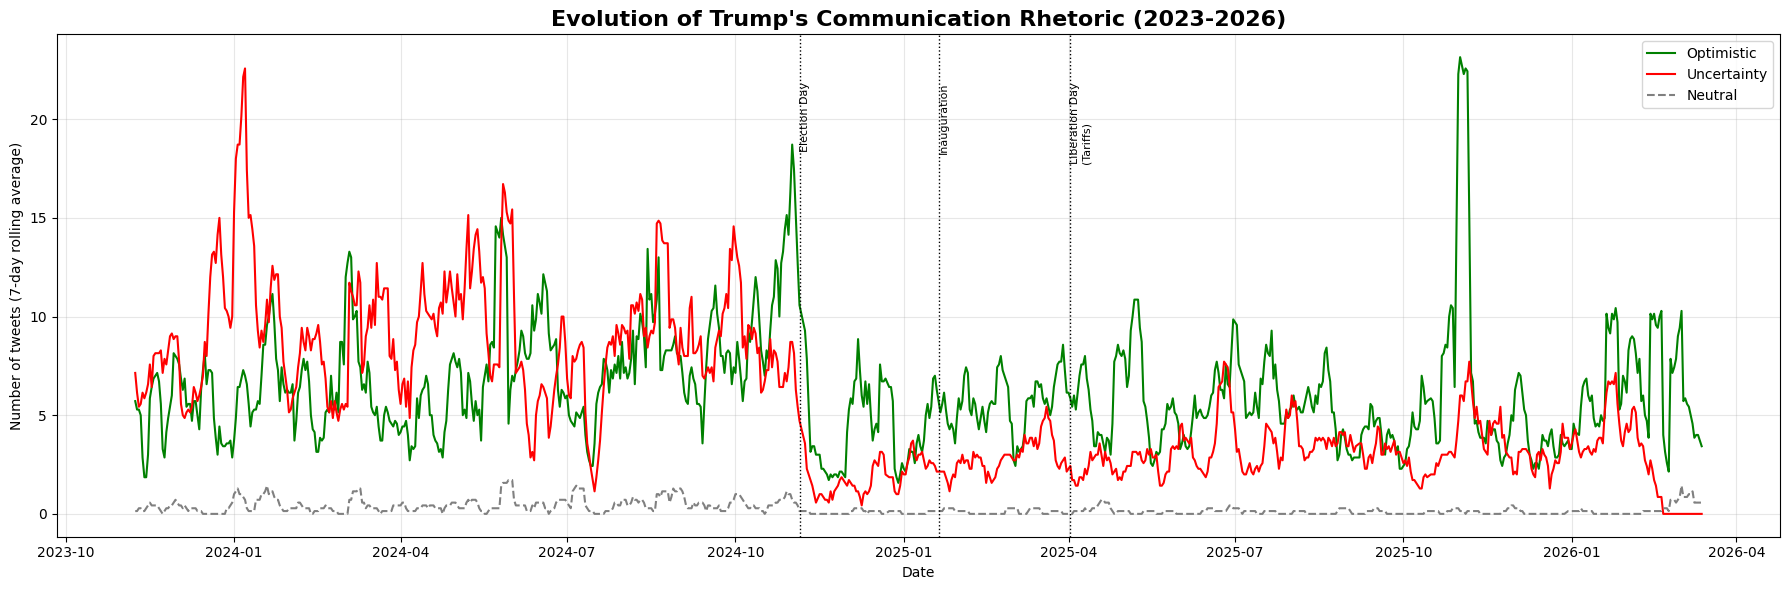

💾 Saved


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Créer un DataFrame à partir des tweets classifiés
df_classified = pd.DataFrame(tweets_to_classify)
df_classified["date"] = pd.to_datetime(df_classified["date"])

# Compter les labels par jour
daily_counts = df_classified.groupby(["date", "bert_label"]).size().unstack(fill_value=0)

# S'assurer que les 3 colonnes existent
for label in ["Optimistic", "Uncertainty", "Neutral"]:
    if label not in daily_counts.columns:
        daily_counts[label] = 0

# Lissage sur 7 jours pour lisibilité
daily_smooth = daily_counts.rolling(7, center=True).mean()

# Plot
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(daily_smooth.index, daily_smooth["Optimistic"],
        color="green", linewidth=1.5, label="Optimistic")
ax.plot(daily_smooth.index, daily_smooth["Uncertainty"],
        color="red", linewidth=1.5, label="Uncertainty")
ax.plot(daily_smooth.index, daily_smooth["Neutral"],
        color="gray", linewidth=1.5, label="Neutral", linestyle="--")

# Annotations événements clés
events = {
    "2024-11-05": "Election Day",
    "2025-01-20": "Inauguration",
    "2025-04-02": "Liberation Day\n(Tariffs)"
}
for date, label in events.items():
    ax.axvline(pd.Timestamp(date), color="black", linestyle=":", linewidth=1)
    ax.text(pd.Timestamp(date), ax.get_ylim()[1]*0.9, label,
            fontsize=8, rotation=90, va="top")

ax.set_title("Evolution of Trump's Communication Rhetoric (2023-2026)",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Number of tweets (7-day rolling average)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(base_path, "rhetoric_evolution.png"), dpi=300, bbox_inches="tight")
plt.show()
print("💾 Saved")

✅ 852 jours dans le rhetoric index
        date  vader_mean  bert_mean  tweet_count  uncertainty_ratio  \
0 2023-11-05    0.076092  -0.538462           13           0.769231   
1 2023-11-06   -0.210465  -0.764706           17           0.882353   
2 2023-11-07   -0.238975   0.000000            4           0.500000   
3 2023-11-08    0.264644   0.370370           27           0.296296   
4 2023-11-09    0.001494   0.000000           16           0.500000   

   optimistic_ratio  rhetoric_index  
0          0.230769       -0.231185  
1          0.117647       -0.487585  
2          0.500000       -0.119487  
3          0.666667        0.317507  
4          0.500000        0.000747  
✅ 1 NaN VIX restants
        date  rhetoric_index    vix
0 2023-11-05       -0.231185    NaN
1 2023-11-06       -0.487585  14.89
2 2023-11-07       -0.119487  14.81
3 2023-11-08        0.317507  14.45
4 2023-11-09        0.000747  15.29
5 2023-11-10        0.381360  14.17
6 2023-11-11        0.004267  14.17
7

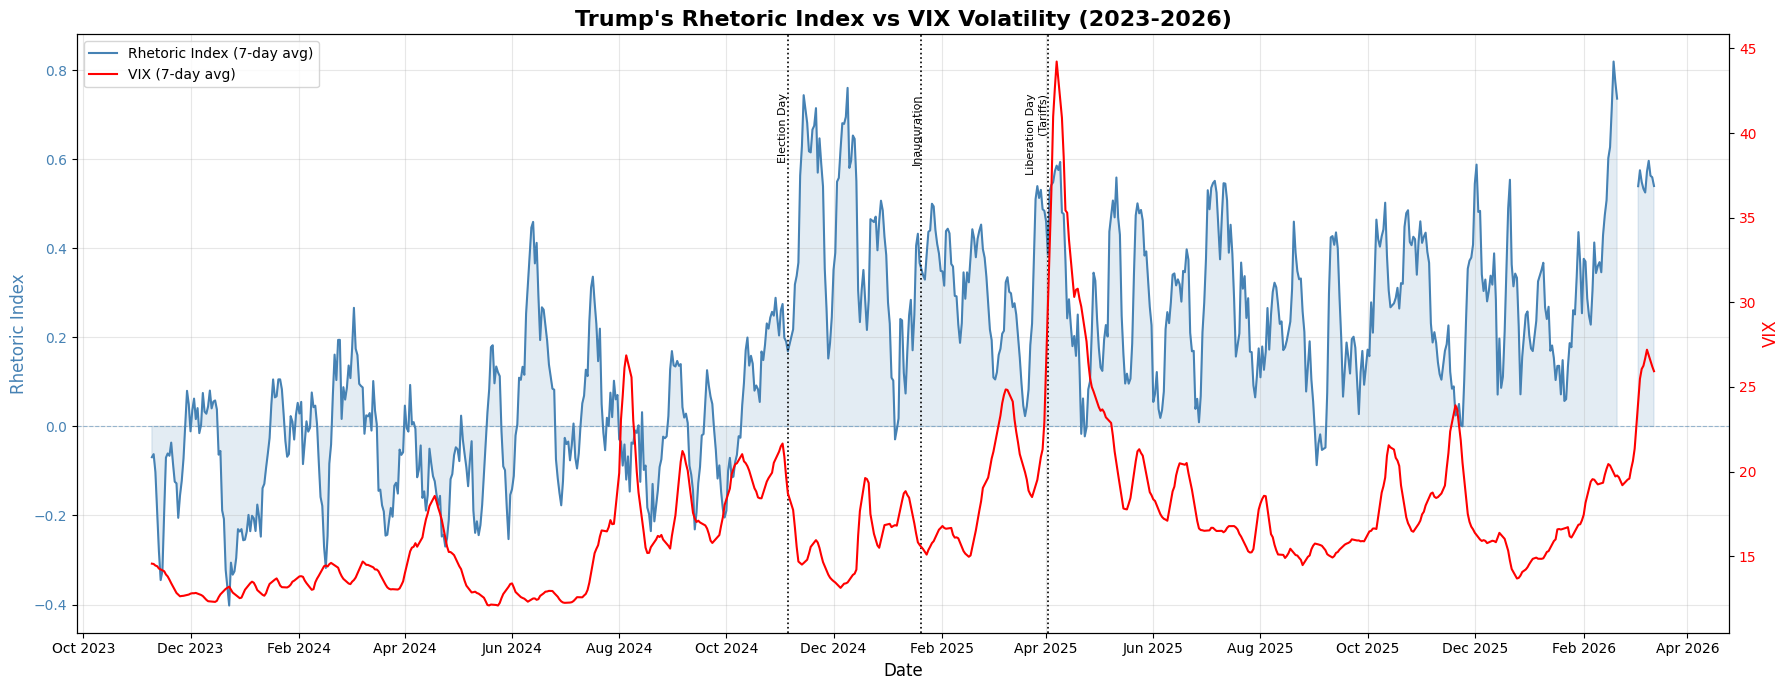

💾 Saved!


In [ ]:
#Rhetoric index vs VIX
import pandas as pd
import numpy as np

# Créer DataFrame avec tous les scores
df_rhetoric = pd.DataFrame(tweets_to_classify)
df_rhetoric["date"] = pd.to_datetime(df_rhetoric["date"])

# Encoder les labels zero-shot en numérique
label_numeric = {"Optimistic": 1, "Neutral": 0, "Uncertainty": -1}
df_rhetoric["bert_numeric"] = df_rhetoric["bert_label"].map(label_numeric)

# Agréger par jour
daily = df_rhetoric.groupby("date").agg(
    vader_mean=("vader_compound", "mean"),       # moyenne VADER
    bert_mean=("bert_numeric", "mean"),           # moyenne zero-shot
    tweet_count=("text", "count"),                # nombre de tweets
    uncertainty_ratio=("bert_label", lambda x: (x == "Uncertainty").mean()),  # % Uncertainty
    optimistic_ratio=("bert_label", lambda x: (x == "Optimistic").mean())     # % Optimistic
).reset_index()

# Rhetoric index = combinaison VADER + zero-shot
daily["rhetoric_index"] = (daily["vader_mean"] + daily["bert_mean"]) / 2

print(f"✅ {len(daily)} jours dans le rhetoric index")
print(daily.head())

#Merge with VIX

vix_daily = filtered_vix_data.copy()
vix_daily["date"] = pd.to_datetime(vix_daily["vix_date"])

daily_merged = daily.merge(vix_daily[["date", "vix"]], on="date", how="left")
daily_merged["vix"] = daily_merged["vix"].ffill()

print(f"✅ {daily_merged['vix'].isna().sum()} NaN VIX restants")
print(daily_merged[["date", "rhetoric_index", "vix"]].head(10))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Supprimer le NaN
plot_data = daily_merged.dropna(subset=["vix"]).copy()

# Lissage 7 jours
plot_data["rhetoric_smooth"] = plot_data["rhetoric_index"].rolling(7, center=True).mean()
plot_data["vix_smooth"] = plot_data["vix"].rolling(7, center=True).mean()

fig, ax1 = plt.subplots(figsize=(18, 7))

# Axe gauche — Rhetoric Index
ax1.plot(plot_data["date"], plot_data["rhetoric_smooth"],
         color="steelblue", linewidth=1.5, label="Rhetoric Index (7-day avg)")
ax1.fill_between(plot_data["date"], plot_data["rhetoric_smooth"],
                  alpha=0.15, color="steelblue")
ax1.set_ylabel("Rhetoric Index", color="steelblue", fontsize=12)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.axhline(0, color="steelblue", linestyle="--", linewidth=0.8, alpha=0.5)

# Axe droit — VIX
ax2 = ax1.twinx()
ax2.plot(plot_data["date"], plot_data["vix_smooth"],
         color="red", linewidth=1.5, label="VIX (7-day avg)")
ax2.set_ylabel("VIX", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")

# Événements clés
events = {
    "2024-11-05": "Election Day",
    "2025-01-20": "Inauguration",
    "2025-04-02": "Liberation Day\n(Tariffs)"
}
for date, label in events.items():
    ax1.axvline(pd.Timestamp(date), color="black", linestyle=":", linewidth=1.2)
    ax1.text(pd.Timestamp(date), ax1.get_ylim()[1]*0.85, label,
             fontsize=8, rotation=90, va="top", ha="right")

# Formatting
ax1.set_xlabel("Date", fontsize=12)
ax1.set_title("Trump's Rhetoric Index vs VIX Volatility (2023-2026)",
              fontsize=16, fontweight="bold")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(base_path, "rhetoric_vs_vix.png"), dpi=300, bbox_inches="tight")
plt.show()
print("💾 Saved!")


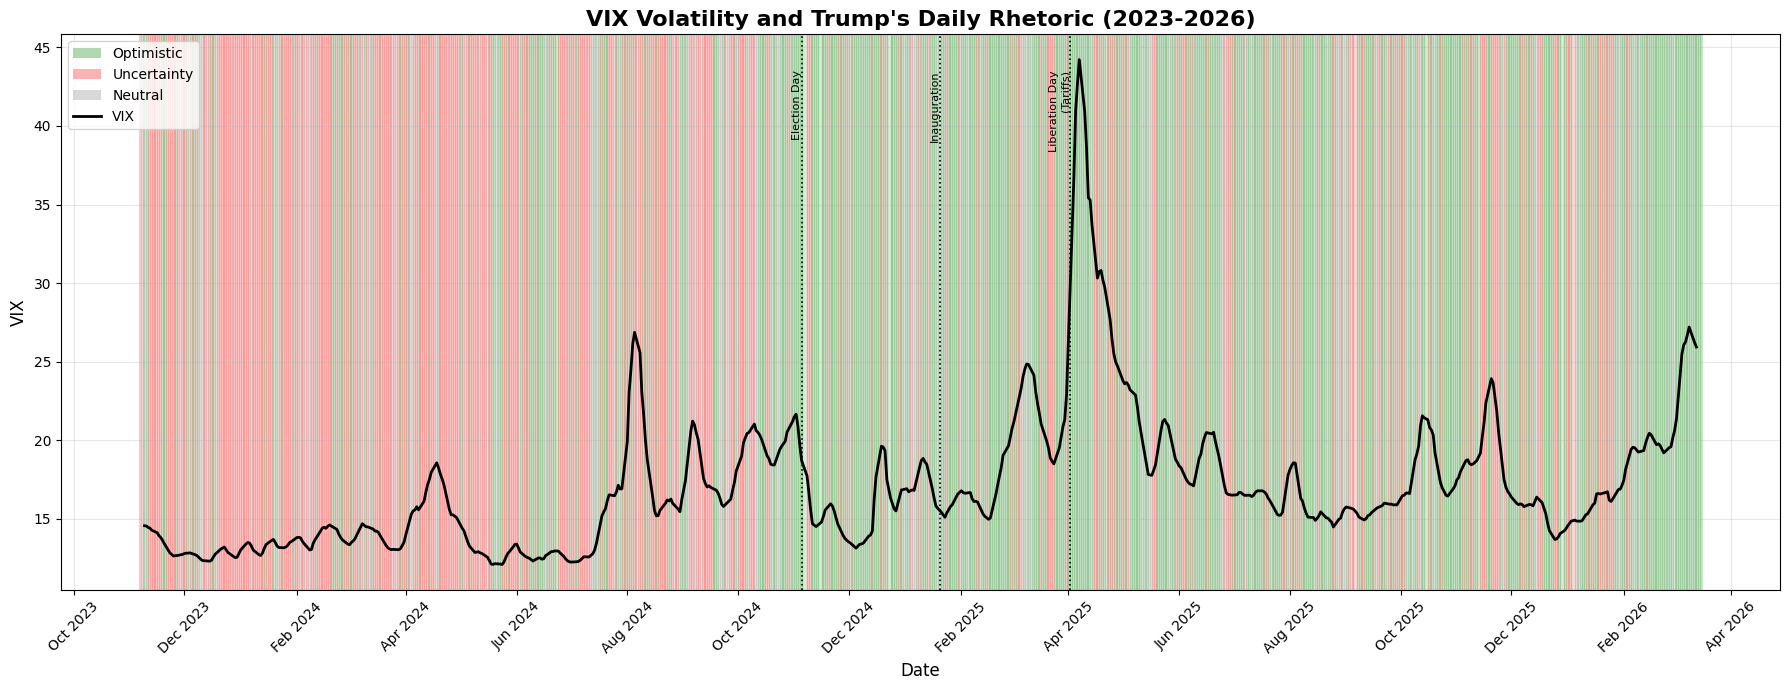

💾 Saved!


In [ ]:
fig, ax = plt.subplots(figsize=(18, 7))

# Couleur de fond selon label dominant du jour
for i in range(len(plot_data) - 1):
    label = plot_data["bert_mean"].iloc[i]
    if label > 0.1:
        color = "green"
    elif label < -0.1:
        color = "red"
    else:
        color = "gray"

    ax.axvspan(
        plot_data["date"].iloc[i],
        plot_data["date"].iloc[i+1],
        alpha=0.15,
        color=color
    )

# VIX
ax.plot(plot_data["date"], plot_data["vix_smooth"],
        color="black", linewidth=2, label="VIX (7-day avg)")

# Événements clés
events = {
    "2024-11-05": "Election Day",
    "2025-01-20": "Inauguration",
    "2025-04-02": "Liberation Day\n(Tariffs)"
}
for date, label in events.items():
    ax.axvline(pd.Timestamp(date), color="black", linestyle=":", linewidth=1.2)
    ax.text(pd.Timestamp(date), ax.get_ylim()[1]*0.95, label,
            fontsize=8, rotation=90, va="top", ha="right")

# Légende manuelle pour les couleurs
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="green", alpha=0.3, label="Optimistic"),
    Patch(facecolor="red", alpha=0.3, label="Uncertainty"),
    Patch(facecolor="gray", alpha=0.3, label="Neutral"),
    plt.Line2D([0], [0], color="black", linewidth=2, label="VIX")
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=10)

ax.set_title("VIX Volatility and Trump's Daily Rhetoric (2023-2026)",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("VIX", fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(base_path, "vix_rhetoric_zones.png"), dpi=300, bbox_inches="tight")
plt.show()
print("💾 Saved!")

# Saving the Data

In order to work with the data, we first need to save it

In [ ]:

# 1. Save daily panel (this is what you need for the regression)
daily_merged.to_csv("daily_trump_vix.csv", index=False)
print(f"✅ daily_trump_vix.csv saved — {len(daily_merged)} rows")
print(daily_merged.columns.tolist())
print(daily_merged.head())

# Also save to Drive
drive_path = os.path.join(base_path, "daily_trump_vix.csv")
daily_merged.to_csv(drive_path, index=False)
print(f"💾 Also saved to {drive_path}")

# 2. Save tweet-level classified data with VADER (backup, useful for robustness)
df_classified_export = pd.DataFrame(tweets_to_classify)
df_classified_export.to_csv("trump_tweets_full.csv", index=False)
drive_path2 = os.path.join(base_path, "trump_tweets_full.csv")
df_classified_export.to_csv(drive_path2, index=False)
print(f"✅ trump_tweets_full.csv saved — {len(df_classified_export)} rows")

# 3. Download from Colab
from google.colab import files
files.download("daily_trump_vix.csv")
files.download("trump_tweets_full.csv")

✅ daily_trump_vix.csv saved — 852 rows
['date', 'vader_mean', 'bert_mean', 'tweet_count', 'uncertainty_ratio', 'optimistic_ratio', 'rhetoric_index', 'vix']
        date  vader_mean  bert_mean  tweet_count  uncertainty_ratio  \
0 2023-11-05    0.076092  -0.538462           13           0.769231   
1 2023-11-06   -0.210465  -0.764706           17           0.882353   
2 2023-11-07   -0.238975   0.000000            4           0.500000   
3 2023-11-08    0.264644   0.370370           27           0.296296   
4 2023-11-09    0.001494   0.000000           16           0.500000   

   optimistic_ratio  rhetoric_index    vix  
0          0.230769       -0.231185    NaN  
1          0.117647       -0.487585  14.89  
2          0.500000       -0.119487  14.81  
3          0.666667        0.317507  14.45  
4          0.500000        0.000747  15.29  
💾 Also saved to /content/drive/MyDrive/Poster/daily_trump_vix.csv
✅ trump_tweets_full.csv saved — 10415 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Ordinary Regression

Before going into RF, I believe we should just do a normal panel FE regression, as we don't really have many variables

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import csv
csv.field_size_limit(10**7)


# 1. LOAD DATA

# --- Trump daily panel (already has: date, rhetoric_index, vader_mean,
#     bert_mean, tweet_count, uncertainty_ratio, optimistic_ratio, vix) ---
trump = pd.read_csv("daily_trump_vix.csv", parse_dates=["date"])
print(f"✅ Trump daily panel: {len(trump)} rows")
print(f"   Columns: {trump.columns.tolist()}")
print(f"   Date range: {trump['date'].min()} → {trump['date'].max()}")

# --- Fed sources ---
speeches = pd.read_csv("all_fed_speeches.csv", parse_dates=["Date"])
press    = pd.read_csv("all_fed_press_releases.csv", parse_dates=["Date"])
fomc = pd.read_csv("fed_statements_and_minutes_since_2020.csv", parse_dates=["Date"], engine="python")

print(f"✅ Fed speeches: {len(speeches)} | Press releases: {len(press)} | FOMC docs: {len(fomc)}")


✅ Trump daily panel: 852 rows
   Columns: ['date', 'vader_mean', 'bert_mean', 'tweet_count', 'uncertainty_ratio', 'optimistic_ratio', 'rhetoric_index', 'vix']
   Date range: 2023-11-05 00:00:00 → 2026-03-16 00:00:00
✅ Fed speeches: 494 | Press releases: 908 | FOMC docs: 490


In [ ]:
# ============================================================
# 2. BUILD FED DUMMY (1 if any Fed publication that day)
# ============================================================

# Collect all unique Fed communication dates
fed_dates = set()
for df_fed in [speeches, press, fomc]:
    valid = df_fed["Date"].dropna()
    fed_dates.update(valid.dt.normalize().unique())

fed_dates = sorted(fed_dates)
print(f"✅ {len(fed_dates)} unique Fed communication days")

# Create lookup DataFrame
fed_dummy = pd.DataFrame({"date": pd.to_datetime(list(fed_dates))})
fed_dummy["fed_comm"] = 1

# ============================================================
# 3. MERGE EVERYTHING INTO REGRESSION PANEL
# ============================================================

panel = trump.copy()
panel["date"] = pd.to_datetime(panel["date"])

# Merge Fed dummy
panel = panel.merge(fed_dummy, on="date", how="left")
panel["fed_comm"] = panel["fed_comm"].fillna(0).astype(int)

# tweet_count already exists from the Trump notebook aggregation
# Rename for clarity in regression output
panel = panel.rename(columns={"tweet_count": "n_tweets"})

# Create regression variables
panel = panel.sort_values("date").reset_index(drop=True)
panel["vix_lag1"]   = panel["vix"].shift(1)          # Lagged VIX (persistence control)
panel["delta_vix"]  = panel["vix"].diff()             # First difference
panel["log_vix"]    = np.log(panel["vix"])
panel["dlog_vix"]   = panel["log_vix"].diff()         # Log-change (% approx)

# Day-of-week dummies (Monday=0 ... Friday=4)
panel["dow"] = panel["date"].dt.dayofweek
dow_dummies = pd.get_dummies(panel["dow"], prefix="dow", drop_first=True, dtype=int)
panel = pd.concat([panel, dow_dummies], axis=1)

# Drop rows with NaN from differencing / lagging
panel_clean = panel.dropna(subset=["delta_vix", "vix_lag1", "rhetoric_index"]).copy()
print(f"\n✅ Regression panel ready: {len(panel_clean)} obs")
print(f"   Fed comm days in sample: {panel_clean['fed_comm'].sum():.0f}")
print(f"   Mean tweets/day: {panel_clean['n_tweets'].mean():.1f}")

✅ 1124 unique Fed communication days

✅ Regression panel ready: 848 obs
   Fed comm days in sample: 346
   Mean tweets/day: 12.2


In [ ]:

# 4. DESCRIPTIVE STATS

desc_vars = ["vix", "delta_vix", "rhetoric_index", "vader_mean",
             "bert_mean", "n_tweets", "uncertainty_ratio", "fed_comm"]
print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
print(panel_clean[desc_vars].describe().round(3).to_string())

# ============================================================
# 5. REGRESSION: ΔvIX ~ rhetoric + n_tweets + fed_comm + controls
# ============================================================
# Using Δvix (first difference) as DV to handle VIX persistence/nonstationarity.
# HAC (Newey-West) standard errors for autocorrelation + heteroskedasticity.

print("\n" + "="*60)
print("MAIN SPECIFICATION: OLS with HAC standard errors")
print("Dependent variable: ΔVIX (daily change in VIX)")
print("="*60)

# --- Model 1: Baseline — rhetoric only ---
X1 = sm.add_constant(panel_clean[["rhetoric_index"]])
y  = panel_clean["delta_vix"]
m1 = sm.OLS(y, X1).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

# --- Model 2: Add tweet volume ---
X2 = sm.add_constant(panel_clean[["rhetoric_index", "n_tweets"]])
m2 = sm.OLS(y, X2).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

# --- Model 3: Add Fed control ---
X3 = sm.add_constant(panel_clean[["rhetoric_index", "n_tweets", "fed_comm"]])
m3 = sm.OLS(y, X3).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

# --- Model 4: Full — add lagged VIX + day-of-week FE ---
dow_cols = [c for c in panel_clean.columns if c.startswith("dow_")]
X4 = sm.add_constant(panel_clean[["rhetoric_index", "n_tweets", "fed_comm",
                                    "vix_lag1"] + dow_cols])
m4 = sm.OLS(y, X4).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

# --- Model 5: Fed control + tweets + rhetoric + lagged VIX, no DOW ---
X5 = sm.add_constant(panel_clean[["rhetoric_index", "n_tweets", "fed_comm", "vix_lag1"]])
m5 = sm.OLS(y, X5).fit(cov_type="HAC", cov_kwds={"maxlags": 5})



# Print full model
print("\n--- Model 1: Rhetoric only ---")
print(m1.summary().tables[1])
print(f"R² = {m1.rsquared:.4f}  |  N = {int(m1.nobs)}")

print("\n--- Model 2: + Tweet volume ---")
print(m2.summary().tables[1])
print(f"R² = {m2.rsquared:.4f}  |  N = {int(m2.nobs)}")

print("\n--- Model 3: + Fed control ---")
print(m3.summary().tables[1])
print(f"R² = {m3.rsquared:.4f}  |  N = {int(m3.nobs)}")

print("\n--- Model 4: Full specification ---")
print(m4.summary())


print("\n--- Model 4: Full specification ---")
print(m4.summary())

print("\n--- Model 5: Final (no DOW dummies) ---")
print(m5.summary())



DESCRIPTIVE STATISTICS
           vix  delta_vix  rhetoric_index  vader_mean  bert_mean  n_tweets  uncertainty_ratio  fed_comm
count  848.000    848.000         848.000     848.000    848.000   848.000            848.000   848.000
mean    17.116      0.012           0.174       0.252      0.095    12.242              0.442     0.408
std      4.724      1.661           0.384       0.338      0.516     9.980              0.261     0.492
min     11.860    -18.710          -0.989      -0.986     -1.000     1.000              0.000     0.000
25%     14.152     -0.303          -0.107       0.021     -0.296     5.000              0.250     0.000
50%     16.090      0.000           0.168       0.234      0.091    10.000              0.444     0.000
75%     18.757      0.210           0.446       0.468      0.500    16.000              0.638     1.000
max     52.330     15.290           0.997       0.994      1.000    77.000              1.000     1.000

MAIN SPECIFICATION: OLS with HAC standa

In [ ]:
# ============================================================
# 6. DECOMPOSED SPECIFICATION (VADER + zero-shot separately)
# ============================================================

print("\n" + "="*60)
print("ROBUSTNESS: Decomposed sentiment measures")
print("="*60)

X5 = sm.add_constant(panel_clean[["vader_mean", "uncertainty_ratio",
                                    "n_tweets", "fed_comm", "vix_lag1"] + dow_cols])
m5 = sm.OLS(y, X5).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print(m5.summary())

panel_clean.to_csv("regression_panel.csv", index=False)
print("\n💾 regression_panel.csv saved")

# Save regression table to text
with open("regression_results.txt", "w") as f:
    f.write("="*70 + "\n")
    f.write("VIX REGRESSION RESULTS\n")
    f.write("Dep var: ΔVIX | HAC(5) standard errors\n")
    f.write("="*70 + "\n\n")
    f.write("--- Model 1: Rhetoric only ---\n")
    f.write(m1.summary().as_text() + "\n\n")
    f.write("--- Model 2: + Tweet volume ---\n")
    f.write(m2.summary().as_text() + "\n\n")
    f.write("--- Model 3: + Fed control ---\n")
    f.write(m3.summary().as_text() + "\n\n")
    f.write("--- Model 4: Full specification ---\n")
    f.write(m4.summary().as_text() + "\n\n")
    f.write("--- Model 5: Decomposed sentiment ---\n")
    f.write(m5.summary().as_text() + "\n")
print("💾 regression_results.txt saved")



ROBUSTNESS: Decomposed sentiment measures
                            OLS Regression Results                            
Dep. Variable:              delta_vix   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     1.425
Date:                Fri, 27 Mar 2026   Prob (F-statistic):              0.156
Time:                        23:16:30   Log-Likelihood:                -1615.5
No. Observations:                 848   AIC:                             3255.
Df Residuals:                     836   BIC:                             3312.
Df Model:                          11                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

It seems that the standard regression doesn't return any significant results. We shall now proceed on the random forest


# Random Forest prediction

=> Do tweets generally predict the VIX?


In [ ]:
"""
Random Forest: ΔVIX prediction from Trump rhetoric + Fed control
================================================================
Run AFTER the OLS regression script, or standalone using regression_panel.csv
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 1. LOAD PANEL
# ============================================================

# If running in same notebook, panel_clean already exists.
# Otherwise load from disk:
try:
    panel_clean
    print("✅ Using panel_clean from memory")
except NameError:
    panel_clean = pd.read_csv("regression_panel.csv", parse_dates=["date"])
    print(f"✅ Loaded regression_panel.csv — {len(panel_clean)} rows")

# ============================================================
# 2. PREPARE FEATURES & TARGET
# ============================================================

# Same features as OLS Model 4 (full spec)
dow_cols = [c for c in panel_clean.columns if c.startswith("dow_")]

feature_cols = ["rhetoric_index", "n_tweets", "fed_comm",
                "vix_lag1", "vader_mean", "bert_mean",
                "uncertainty_ratio", "optimistic_ratio"] + dow_cols

X = panel_clean[feature_cols].copy()
y = panel_clean["delta_vix"].copy()

# Drop any remaining NaN
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]
dates = panel_clean.loc[mask, "date"]

print(f"✅ Features: {X.columns.tolist()}")
print(f"   Shape: X={X.shape}, y={y.shape}")

# ============================================================
# 3. TIME-SERIES SPLIT (no data leakage)
# ============================================================
# Important: we do NOT use random train/test split for time series.
# We use a temporal cutoff: train on the past, test on the future.

split_ratio = 0.8
split_idx = int(len(X) * split_ratio)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = dates.iloc[split_idx:]

print(f"\n📊 Train: {len(X_train)} obs ({dates.iloc[0].date()} → {dates.iloc[split_idx-1].date()})")
print(f"   Test:  {len(X_test)} obs ({dates.iloc[split_idx].date()} → {dates.iloc[-1].date()})")



✅ Using panel_clean from memory
✅ Features: ['rhetoric_index', 'n_tweets', 'fed_comm', 'vix_lag1', 'vader_mean', 'bert_mean', 'uncertainty_ratio', 'optimistic_ratio', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']
   Shape: X=(848, 14), y=(848,)

📊 Train: 678 obs (2023-11-07 → 2025-09-21)
   Test:  170 obs (2025-09-22 → 2026-03-16)



📏 Naive baseline (predict ΔVIX=0):
   MSE=2.0089  MAE=0.8402

🌲 Random Forest (default):
   Train — R²=0.1413  MSE=2.5280
   Test  — R²=-0.0011  MSE=2.0080  MAE=0.8557
   vs Naive: MSE ratio = 1.000 (< 1 = RF beats naive)

🔄 5-Fold Time-Series CV:
   MSE per fold: [np.float64(3.41287845907655), np.float64(2.5293248610589143), np.float64(7.586187675106242), np.float64(1.2947726622145417), np.float64(1.809799438694331)]
   Mean MSE: 3.3266 ± 2.2457

⚙️  Tuning hyperparameters (GridSearch with TimeSeriesSplit)...
   Best params: {'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 300}
   Tuned Test — R²=0.0159  MSE=1.9738


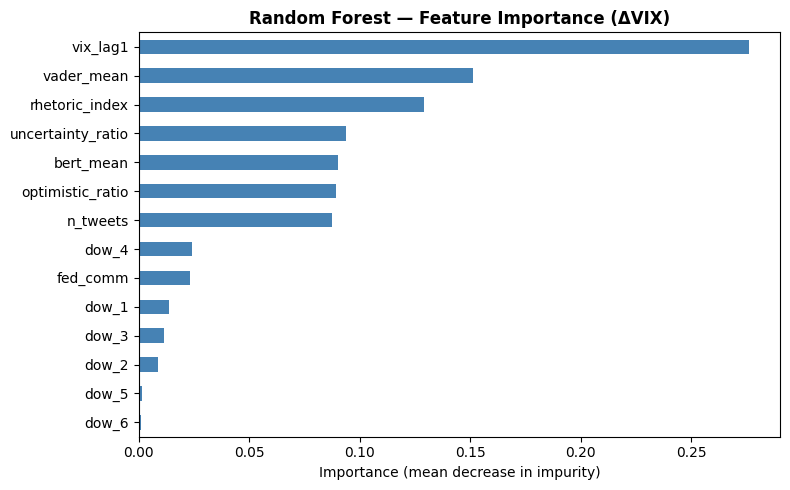

💾 rf_feature_importance.png saved


In [ ]:
# ============================================================
# 4. BASELINE: Naive forecast (ΔVIX = 0, i.e., VIX stays flat)
# ============================================================

naive_mse  = mean_squared_error(y_test, np.zeros(len(y_test)))
naive_mae  = mean_absolute_error(y_test, np.zeros(len(y_test)))
print(f"\n📏 Naive baseline (predict ΔVIX=0):")
print(f"   MSE={naive_mse:.4f}  MAE={naive_mae:.4f}")

# ============================================================
# 5. RANDOM FOREST — DEFAULT
# ============================================================

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

print(f"\n🌲 Random Forest (default):")
print(f"   Train — R²={r2_score(y_train, y_pred_train):.4f}  MSE={mean_squared_error(y_train, y_pred_train):.4f}")
print(f"   Test  — R²={r2_score(y_test, y_pred_test):.4f}  MSE={mean_squared_error(y_test, y_pred_test):.4f}  MAE={mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"   vs Naive: MSE ratio = {mean_squared_error(y_test, y_pred_test)/naive_mse:.3f} (< 1 = RF beats naive)")

# ============================================================
# 6. CROSS-VALIDATION (time-series aware)
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(rf, X, y, cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1)
print(f"\n🔄 5-Fold Time-Series CV:")
print(f"   MSE per fold: {[-s for s in cv_scores]}")
print(f"   Mean MSE: {-cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ============================================================
# 7. HYPERPARAMETER TUNING (optional — takes ~1 min)
# ============================================================

print("\n⚙️  Tuning hyperparameters (GridSearch with TimeSeriesSplit)...")

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [5, 10, 20],
    "min_samples_leaf": [5, 10, 20],
}

grid = GridSearchCV(
    RandomForestRegressor(max_features="sqrt", random_state=42, n_jobs=-1),
    param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print(f"   Best params: {grid.best_params_}")
print(f"   Tuned Test — R²={r2_score(y_test, y_pred_tuned):.4f}  MSE={mean_squared_error(y_test, y_pred_tuned):.4f}")

# ============================================================
# 8. FEATURE IMPORTANCE
# ============================================================

importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Random Forest — Feature Importance (ΔVIX)", fontweight="bold")
ax.set_xlabel("Importance (mean decrease in impurity)")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 rf_feature_importance.png saved")



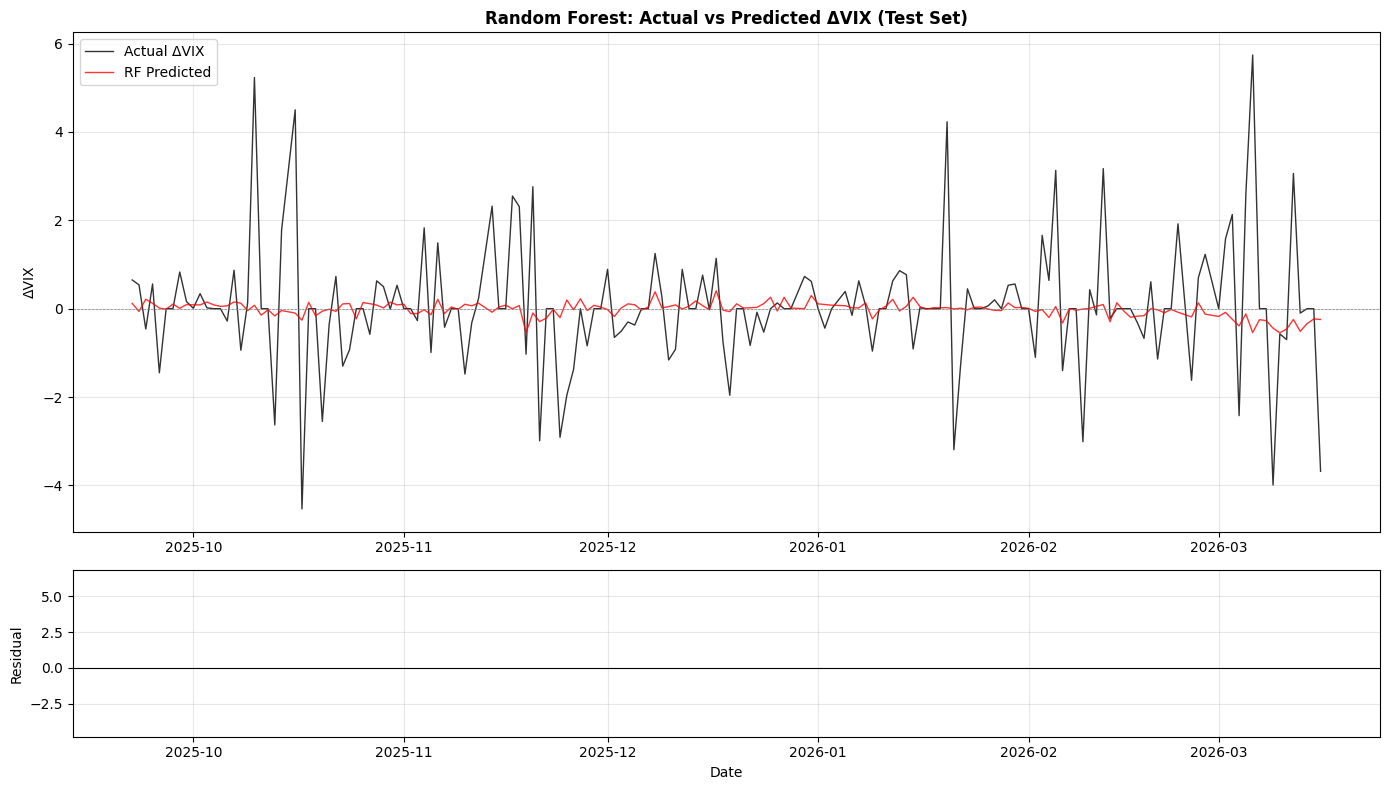

💾 rf_actual_vs_predicted.png saved

🎯 Direction accuracy (sign of ΔVIX):
   RF:    38.8%
   Naive: 31.8% (always predict 0 = no change)
   Random: ~50%


In [ ]:
# ============================================================
# 9. ACTUAL vs PREDICTED PLOT
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 1]})

# Top: time series
axes[0].plot(dates_test.values, y_test.values, color="black", linewidth=1, label="Actual ΔVIX", alpha=0.8)
axes[0].plot(dates_test.values, y_pred_tuned, color="red", linewidth=1, label="RF Predicted", alpha=0.8)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.5)
axes[0].set_title("Random Forest: Actual vs Predicted ΔVIX (Test Set)", fontweight="bold")
axes[0].set_ylabel("ΔVIX")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: residuals
residuals = y_test.values - y_pred_tuned
axes[1].bar(dates_test.values, residuals, color="steelblue", alpha=0.6, width=1)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Residual")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rf_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 rf_actual_vs_predicted.png saved")

# ============================================================
# 10. DIRECTION ACCURACY (does RF get the sign of ΔVIX right?)
# ============================================================

direction_actual = np.sign(y_test.values)
direction_pred   = np.sign(y_pred_tuned)
direction_acc    = (direction_actual == direction_pred).mean()

print(f"\n🎯 Direction accuracy (sign of ΔVIX):")
print(f"   RF:    {direction_acc:.1%}")
print(f"   Naive: {(direction_actual == 0).mean():.1%} (always predict 0 = no change)")
print(f"   Random: ~50%")



In [ ]:
# ============================================================
# 11. SUMMARY TABLE: OLS vs RF
# ============================================================

print("\n" + "="*60)
print("COMPARISON: OLS (Model 4) vs Random Forest")
print("="*60)

# Quick OLS on same train/test split for fair comparison
import statsmodels.api as sm
X_ols_train = sm.add_constant(X_train)
X_ols_test  = sm.add_constant(X_test)
ols = sm.OLS(y_train, X_ols_train).fit()
y_ols_pred = ols.predict(X_ols_test)

ols_direction = (np.sign(y_test.values) == np.sign(y_ols_pred.values)).mean()

print(f"{'Metric':<25} {'OLS':>10} {'RF (tuned)':>12} {'Naive':>10}")
print("-" * 60)
print(f"{'Test MSE':<25} {mean_squared_error(y_test, y_ols_pred):>10.4f} {mean_squared_error(y_test, y_pred_tuned):>12.4f} {naive_mse:>10.4f}")
print(f"{'Test MAE':<25} {mean_absolute_error(y_test, y_ols_pred):>10.4f} {mean_absolute_error(y_test, y_pred_tuned):>12.4f} {naive_mae:>10.4f}")
print(f"{'Test R²':<25} {r2_score(y_test, y_ols_pred):>10.4f} {r2_score(y_test, y_pred_tuned):>12.4f} {'—':>10}")
print(f"{'Direction accuracy':<25} {ols_direction:>10.1%} {direction_acc:>12.1%} {'~50%':>10}")


COMPARISON: OLS (Model 4) vs Random Forest
Metric                           OLS   RF (tuned)      Naive
------------------------------------------------------------
Test MSE                      2.0071       1.9738     2.0089
Test MAE                      0.8726       0.8487     0.8402
Test R²                      -0.0007       0.0159          —
Direction accuracy             37.6%        38.8%       ~50%


Once again, the random forest is not particularly good. I personally attribute it to the fact that we have almost no variables. Ideally we could use plent of data on normal day events, but this is a bit beyond the scope.

#Event study

We will use a rolling window to classify an "unexpected tweet" as when tweets were before going on a bad direction consecutively and then it turns good. But this is measured using Z-scores. To try to be somewhat rigorous, we will only do this "unexpected" when it turns extremely negative or positive. otherwise it might be fallible to VADER or BERT's misclassifications.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 1. LOAD PANEL
# ============================================================

try:
    panel_clean
    print("✅ Using panel_clean from memory")
except NameError:
    panel_clean = pd.read_csv("regression_panel.csv", parse_dates=["date"])
    print(f"✅ Loaded regression_panel.csv — {len(panel_clean)} rows")

df = panel_clean.sort_values("date").reset_index(drop=True).copy()

# ============================================================
# 2. ROLLING Z-SCORE: Identify surprise days
# ============================================================

WINDOW = 14           # trading days for rolling baseline
Z_THRESHOLD = 1.5     # |z| > threshold = surprise

# Rolling mean and std of rhetoric_index
df["rhetoric_roll_mean"] = df["rhetoric_index"].rolling(WINDOW, min_periods=7).mean()
df["rhetoric_roll_std"]  = df["rhetoric_index"].rolling(WINDOW, min_periods=7).std()

# Z-score: how far is today from its own recent baseline
df["rhetoric_z"] = (
    (df["rhetoric_index"] - df["rhetoric_roll_mean"]) / df["rhetoric_roll_std"]
)

# Classify surprises
df["surprise"] = "none"
df.loc[df["rhetoric_z"] >  Z_THRESHOLD, "surprise"] = "positive"   # unexpectedly optimistic
df.loc[df["rhetoric_z"] < -Z_THRESHOLD, "surprise"] = "negative"   # unexpectedly aggressive

n_pos = (df["surprise"] == "positive").sum()
n_neg = (df["surprise"] == "negative").sum()
print(f"\n📊 Surprise identification (window={WINDOW}, |z|>{Z_THRESHOLD}):")
print(f"   Positive surprises (unexpected optimism): {n_pos}")
print(f"   Negative surprises (unexpected aggression): {n_neg}")
print(f"   Normal days: {len(df) - n_pos - n_neg}")



✅ Using panel_clean from memory

📊 Surprise identification (window=14, |z|>1.5):
   Positive surprises (unexpected optimism): 50
   Negative surprises (unexpected aggression): 53
   Normal days: 745


In [ ]:
# ============================================================
# 3. COMPUTE "NORMAL" ΔVIX via OLS (for abnormal returns)
# ============================================================
# We estimate a simple model on NON-event days, then use it to
# predict expected ΔVIX on ALL days. The residual = abnormal ΔVIX.

dow_cols = [c for c in df.columns if c.startswith("dow_")]

# Estimation window: non-surprise days only
est_mask = (df["surprise"] == "none") & df["delta_vix"].notna() & df["vix_lag1"].notna()

X_est = sm.add_constant(df.loc[est_mask, ["vix_lag1", "fed_comm", "n_tweets"] + dow_cols])
y_est = df.loc[est_mask, "delta_vix"]

ols_normal = sm.OLS(y_est, X_est).fit()
print(f"\n📈 Normal-return model (estimated on {len(y_est)} non-event days):")
print(f"   R² = {ols_normal.rsquared:.4f}")

# Predict expected ΔVIX for ALL days
X_all = sm.add_constant(df[["vix_lag1", "fed_comm", "n_tweets"] + dow_cols])
df["delta_vix_expected"] = ols_normal.predict(X_all)
df["abnormal_vix"] = df["delta_vix"] - df["delta_vix_expected"]

# ============================================================
# 4. EVENT WINDOWS: Extract [-PRE, +POST] around each event
# ============================================================

PRE_WINDOW  = 2    # trading days before event
POST_WINDOW = 5    # trading days after event
TOTAL_WINDOW = PRE_WINDOW + 1 + POST_WINDOW  # includes event day (t=0)

def extract_event_windows(df, event_type, pre=PRE_WINDOW, post=POST_WINDOW):
    """Extract abnormal ΔVIX in a window around each surprise day."""
    event_idx = df.index[df["surprise"] == event_type].tolist()
    windows = []
    event_dates = []

    for idx in event_idx:
        start = idx - pre
        end   = idx + post

        # Skip if window goes out of bounds
        if start < 0 or end >= len(df):
            continue

        # Skip if windows overlap with another event (contamination)
        window_range = set(range(start, end + 1))
        other_events = set(df.index[
            (df["surprise"] != "none") & (df.index != idx)
        ])
        if window_range & other_events:
            continue

        window = df.loc[start:end, "abnormal_vix"].values
        if len(window) == pre + post + 1 and not np.any(np.isnan(window)):
            windows.append(window)
            event_dates.append(df.loc[idx, "date"])

    if not windows:
        return None, []

    return np.array(windows), event_dates  # shape: (n_events, window_length)


pos_windows, pos_dates = extract_event_windows(df, "positive")
neg_windows, neg_dates = extract_event_windows(df, "negative")

print(f"\n📐 Event windows extracted (no overlap, no edge effects):")
print(f"   Positive surprises: {len(pos_dates)} clean events")
print(f"   Negative surprises: {len(neg_dates)} clean events")

# ============================================================
# 5. COMPUTE CAR (Cumulative Abnormal Return) + TESTS
# ============================================================

def compute_car_stats(windows, pre, post, label):
    """Compute AAR, CAR, and significance tests."""
    n_events = windows.shape[0]
    tau = np.arange(-pre, post + 1)  # event time [-2, -1, 0, 1, 2, 3, 4, 5]

    # Average Abnormal Return (AAR) per event-time
    aar = windows.mean(axis=0)
    aar_se = windows.std(axis=0) / np.sqrt(n_events)

    # Cumulative Abnormal Return (CAR), cumulated from t=-PRE
    car = np.cumsum(aar)
    # CAR standard error (assuming independence across events)
    car_se = np.sqrt(np.cumsum(aar_se**2))

    # t-tests at each event-time for AAR
    t_stats_aar = aar / aar_se
    p_vals_aar  = 2 * stats.t.sf(np.abs(t_stats_aar), df=n_events - 1)

    # Key windows for significance
    car_0     = car[pre]                 # CAR at t=0
    car_0_2   = car[pre + 2]             # CAR [0, +2]
    car_0_5   = car[-1]                  # CAR [0, +5] = full post-event
    car_post  = windows[:, pre:].sum(axis=1)  # per-event CAR [0, +POST]

    # Cross-sectional t-test on CAR[0, +POST]
    t_car, p_car = stats.ttest_1samp(car_post, 0)

    # Wilcoxon signed-rank (non-parametric robustness)
    if n_events >= 10:
        w_stat, p_wilcox = stats.wilcoxon(car_post)
    else:
        w_stat, p_wilcox = np.nan, np.nan

    # Sign test
    n_positive = (car_post > 0).sum()
    p_sign = stats.binomtest(n_positive, n_events, 0.5).pvalue if n_events > 0 else np.nan

    print(f"\n{'='*60}")
    print(f"  {label}  (N = {n_events} events)")
    print(f"{'='*60}")
    print(f"\n  Event-time | AAR      | t-stat  | p-val  | CAR")
    print(f"  {'-'*55}")
    for i, t in enumerate(tau):
        sig = ""
        if p_vals_aar[i] < 0.01: sig = "***"
        elif p_vals_aar[i] < 0.05: sig = "**"
        elif p_vals_aar[i] < 0.10: sig = "*"
        print(f"  t={t:+d}        | {aar[i]:+.4f}  | {t_stats_aar[i]:+.3f}  | {p_vals_aar[i]:.3f}  | {car[i]:+.4f} {sig}")

    print(f"\n  Key CAR windows:")
    print(f"    CAR[0]       = {car_0:+.4f}")
    print(f"    CAR[0,+2]    = {car_0_2:+.4f}")
    print(f"    CAR[0,+{post}]   = {car_0_5:+.4f}")

    print(f"\n  Significance tests on CAR[0,+{post}]:")
    print(f"    t-test:       t={t_car:+.3f}  p={p_car:.4f} {'***' if p_car<0.01 else '**' if p_car<0.05 else '*' if p_car<0.1 else ''}")
    if not np.isnan(p_wilcox):
        print(f"    Wilcoxon:     W={w_stat:.1f}   p={p_wilcox:.4f} {'***' if p_wilcox<0.01 else '**' if p_wilcox<0.05 else '*' if p_wilcox<0.1 else ''}")
    print(f"    Sign test:    {n_positive}/{n_events} positive  p={p_sign:.4f} {'***' if p_sign<0.01 else '**' if p_sign<0.05 else '*' if p_sign<0.1 else ''}")

    return {"tau": tau, "aar": aar, "aar_se": aar_se, "car": car,
            "car_se": car_se, "n_events": n_events, "car_post": car_post}


# Run for both types
results = {}
if pos_windows is not None and len(pos_dates) >= 3:
    results["positive"] = compute_car_stats(pos_windows, PRE_WINDOW, POST_WINDOW,
                                             "POSITIVE SURPRISES (unexpected optimism)")
if neg_windows is not None and len(neg_dates) >= 3:
    results["negative"] = compute_car_stats(neg_windows, PRE_WINDOW, POST_WINDOW,
                                             "NEGATIVE SURPRISES (unexpected aggression)")




📈 Normal-return model (estimated on 745 non-event days):
   R² = 0.0428

📐 Event windows extracted (no overlap, no edge effects):
   Positive surprises: 19 clean events
   Negative surprises: 19 clean events

  POSITIVE SURPRISES (unexpected optimism)  (N = 19 events)

  Event-time | AAR      | t-stat  | p-val  | CAR
  -------------------------------------------------------
  t=-2        | -0.0996  | -0.497  | 0.625  | -0.0996 
  t=-1        | -0.2931  | -1.092  | 0.289  | -0.3927 
  t=+0        | -0.1890  | -1.439  | 0.167  | -0.5817 
  t=+1        | +0.4603  | +1.118  | 0.278  | -0.1214 
  t=+2        | +0.4066  | +1.523  | 0.145  | +0.2852 
  t=+3        | +0.0295  | +0.150  | 0.882  | +0.3147 
  t=+4        | +0.0139  | +0.049  | 0.961  | +0.3286 
  t=+5        | +0.2887  | +0.576  | 0.572  | +0.6173 

  Key CAR windows:
    CAR[0]       = -0.5817
    CAR[0,+2]    = +0.2852
    CAR[0,+5]   = +0.6173

  Significance tests on CAR[0,+5]:
    t-test:       t=+1.194  p=0.2479 
    Wilc

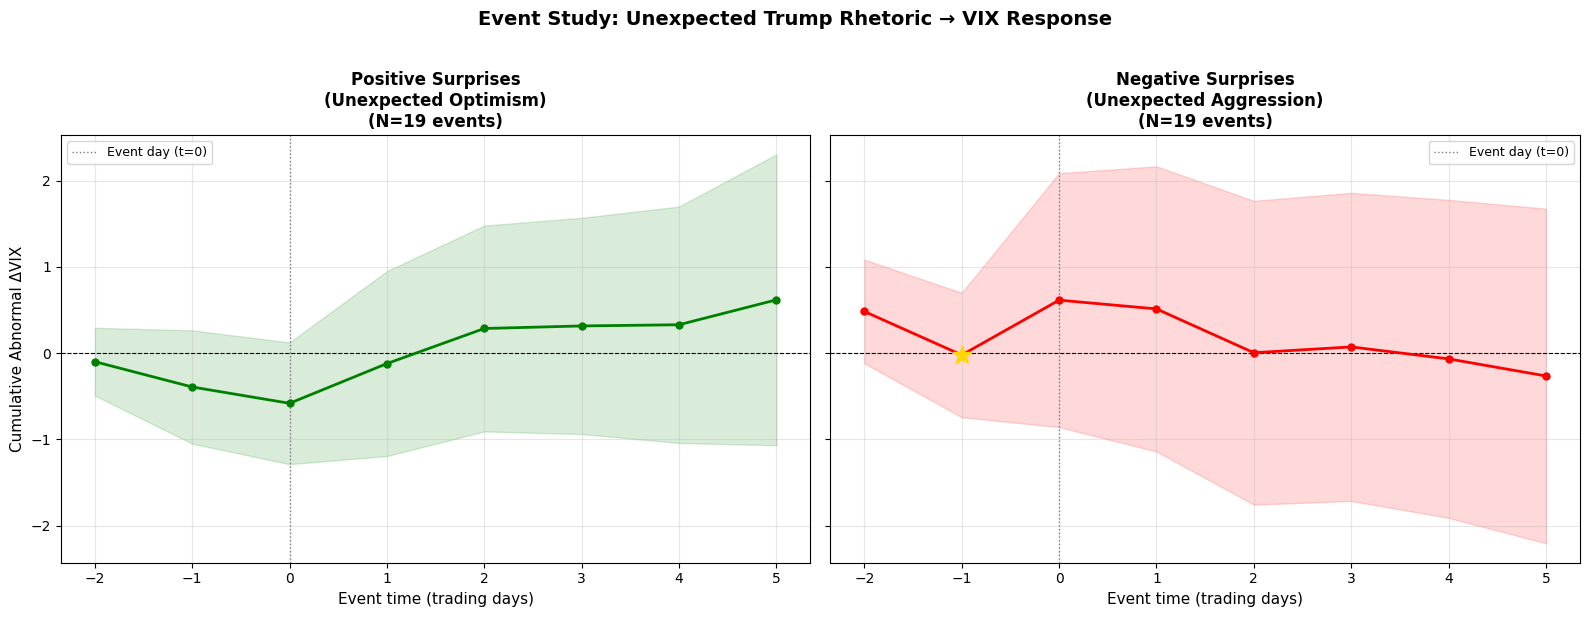

💾 event_study_car.png saved


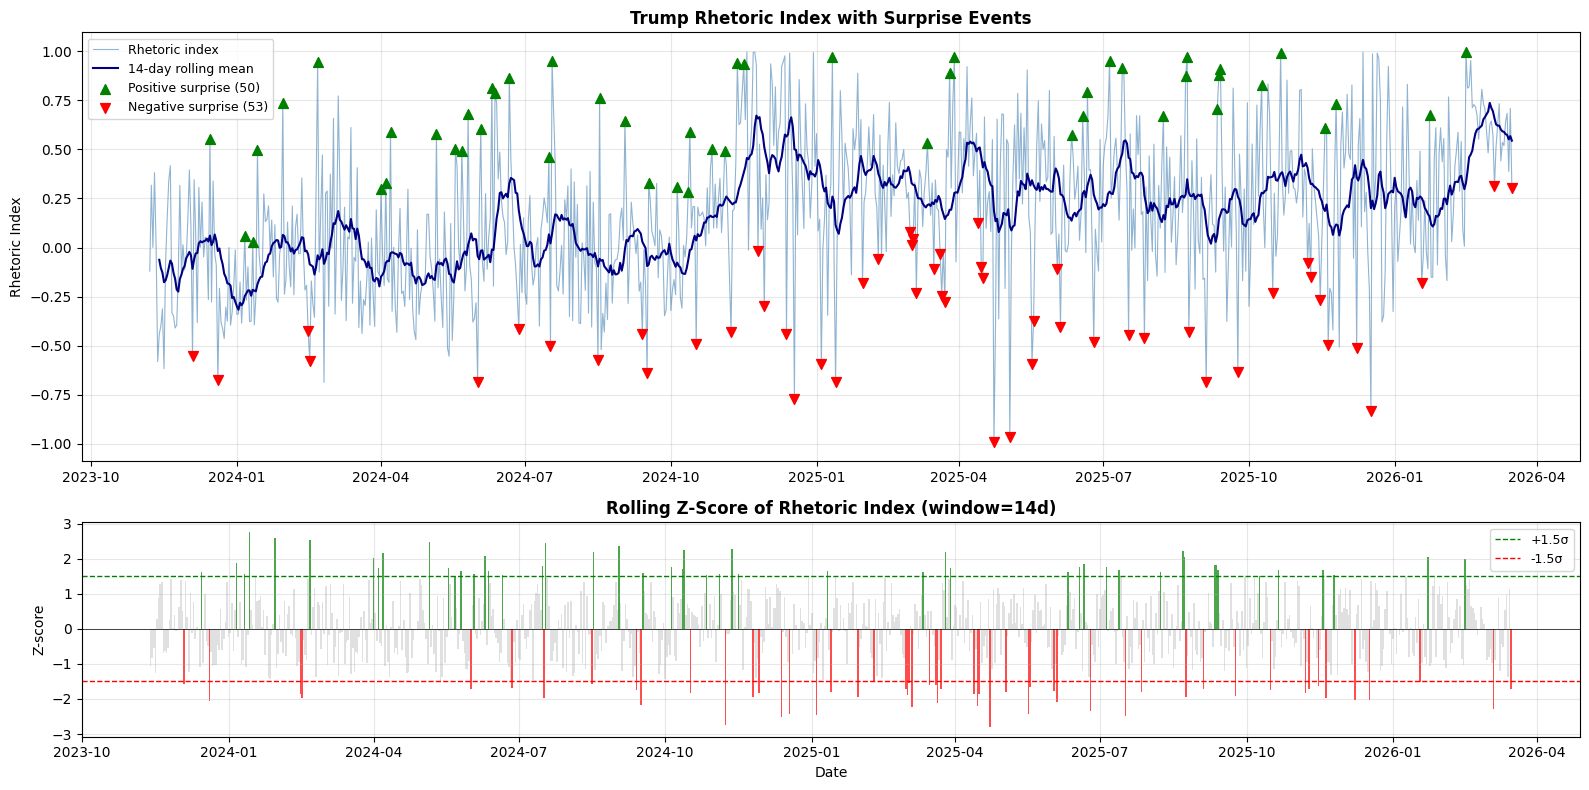

💾 event_study_zscore_timeline.png saved


In [ ]:
# ============================================================
# 6. EVENT STUDY PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, (key, color, title) in zip(axes, [
    ("positive", "green",  "Positive Surprises\n(Unexpected Optimism)"),
    ("negative", "red",    "Negative Surprises\n(Unexpected Aggression)")
]):
    if key not in results:
        ax.set_title(f"{title}\n(insufficient events)", fontsize=12)
        ax.set_visible(False)
        continue

    r = results[key]
    tau, car, car_se, n = r["tau"], r["car"], r["car_se"], r["n_events"]

    # CAR line
    ax.plot(tau, car, color=color, linewidth=2, marker="o", markersize=5, zorder=3)

    # 95% CI band
    ax.fill_between(tau, car - 1.96 * car_se, car + 1.96 * car_se,
                    color=color, alpha=0.15, zorder=1)

    # Reference lines
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="gray",  linewidth=1,   linestyle=":", label="Event day (t=0)")

    # Highlight significant AARs
    for i, t in enumerate(tau):
        t_stat = r["aar"][i] / r["aar_se"][i]
        p_val = 2 * stats.t.sf(abs(t_stat), df=n - 1)
        if p_val < 0.05:
            ax.plot(t, car[i], marker="*", color="gold", markersize=14, zorder=4)

    ax.set_title(f"{title}\n(N={n} events)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Event time (trading days)", fontsize=11)
    ax.set_ylabel("Cumulative Abnormal ΔVIX" if ax == axes[0] else "", fontsize=11)
    ax.set_xticks(tau)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle("Event Study: Unexpected Trump Rhetoric → VIX Response",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("event_study_car.png", dpi=200, bbox_inches="tight")
plt.show()
print("💾 event_study_car.png saved")

# ============================================================
# 7. Z-SCORE TIME SERIES + EVENT MARKERS
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={"height_ratios": [2, 1]})

# Top: rhetoric_index with surprise markers
ax1 = axes[0]
ax1.plot(df["date"], df["rhetoric_index"], color="steelblue", linewidth=0.8, alpha=0.6, label="Rhetoric index")
ax1.plot(df["date"], df["rhetoric_roll_mean"], color="navy", linewidth=1.5, label=f"{WINDOW}-day rolling mean")

pos_mask = df["surprise"] == "positive"
neg_mask = df["surprise"] == "negative"
ax1.scatter(df.loc[pos_mask, "date"], df.loc[pos_mask, "rhetoric_index"],
            color="green", s=50, zorder=5, label=f"Positive surprise ({pos_mask.sum()})", marker="^")
ax1.scatter(df.loc[neg_mask, "date"], df.loc[neg_mask, "rhetoric_index"],
            color="red", s=50, zorder=5, label=f"Negative surprise ({neg_mask.sum()})", marker="v")

ax1.set_ylabel("Rhetoric Index")
ax1.set_title("Trump Rhetoric Index with Surprise Events", fontweight="bold")
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(True, alpha=0.3)

# Bottom: z-score with threshold bands
ax2 = axes[1]
ax2.bar(df["date"], df["rhetoric_z"], width=1,
        color=np.where(df["rhetoric_z"] > Z_THRESHOLD, "green",
              np.where(df["rhetoric_z"] < -Z_THRESHOLD, "red", "lightgray")),
        alpha=0.7)
ax2.axhline( Z_THRESHOLD, color="green", linestyle="--", linewidth=1, label=f"+{Z_THRESHOLD}σ")
ax2.axhline(-Z_THRESHOLD, color="red",   linestyle="--", linewidth=1, label=f"-{Z_THRESHOLD}σ")
ax2.axhline(0, color="black", linewidth=0.5)

ax2.set_ylabel("Z-score")
ax2.set_xlabel("Date")
ax2.set_title(f"Rolling Z-Score of Rhetoric Index (window={WINDOW}d)", fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("event_study_zscore_timeline.png", dpi=200, bbox_inches="tight")
plt.show()
print("💾 event_study_zscore_timeline.png saved")



Non-significantttt noooooooooo

In [ ]:
# ============================================================
# 8. INDIVIDUAL EVENT DETAIL TABLE
# ============================================================

print("\n" + "="*60)
print("INDIVIDUAL SURPRISE EVENTS")
print("="*60)

for event_type, dates_list, label in [
    ("positive", pos_dates, "POSITIVE (unexpected optimism)"),
    ("negative", neg_dates, "NEGATIVE (unexpected aggression)")
]:
    print(f"\n  {label}:")
    print(f"  {'Date':<14} {'Rhetoric':>10} {'Z-score':>10} {'ΔVIX(t=0)':>10} {'ΔVIX(t+1)':>10}")
    print(f"  {'-'*56}")
    for d in dates_list:
        row = df[df["date"] == d].iloc[0]
        idx = df[df["date"] == d].index[0]
        dvix_t1 = df.loc[idx + 1, "delta_vix"] if idx + 1 < len(df) else np.nan
        print(f"  {str(d.date()):<14} {row['rhetoric_index']:>+10.3f} {row['rhetoric_z']:>+10.2f} "
              f"{row['delta_vix']:>+10.3f} {dvix_t1:>+10.3f}")

# ============================================================
# 9. ROBUSTNESS: Alternative thresholds
# ============================================================

print("\n" + "="*60)
print("ROBUSTNESS: CAR[0,+5] across different z-score thresholds")
print("="*60)
print(f"  {'Threshold':<12} {'N(pos)':>8} {'CAR(pos)':>10} {'p-val':>8} {'N(neg)':>8} {'CAR(neg)':>10} {'p-val':>8}")
print(f"  {'-'*68}")

for z_thresh in [1.0, 1.25, 1.5, 1.75, 2.0]:
    df["_surp"] = "none"
    df.loc[df["rhetoric_z"] >  z_thresh, "_surp"] = "positive"
    df.loc[df["rhetoric_z"] < -z_thresh, "_surp"] = "negative"

    for sign, col_car, col_p in [("positive", "", ""), ("negative", "", "")]:
        idx_list = df.index[df["_surp"] == sign].tolist()
        cars = []
        for idx in idx_list:
            if idx - PRE_WINDOW < 0 or idx + POST_WINDOW >= len(df):
                continue
            window = df.loc[idx:idx + POST_WINDOW, "abnormal_vix"].values
            if len(window) == POST_WINDOW + 1 and not np.any(np.isnan(window)):
                cars.append(window.sum())

        if sign == "positive":
            n_p, car_p, p_p = len(cars), np.mean(cars) if cars else np.nan, np.nan
            if len(cars) >= 3:
                _, p_p = stats.ttest_1samp(cars, 0)
        else:
            n_n, car_n, p_n = len(cars), np.mean(cars) if cars else np.nan, np.nan
            if len(cars) >= 3:
                _, p_n = stats.ttest_1samp(cars, 0)

    print(f"  |z|>{z_thresh:<5.2f}    {n_p:>8d} {car_p:>+10.4f} {p_p:>8.3f} {n_n:>8d} {car_n:>+10.4f} {p_n:>8.3f}")

df.drop(columns=["_surp"], inplace=True)




INDIVIDUAL SURPRISE EVENTS

  POSITIVE (unexpected optimism):
  Date             Rhetoric    Z-score  ΔVIX(t=0)  ΔVIX(t+1)
  --------------------------------------------------------
  2024-01-14         +0.495      +2.76     +0.000     +0.000
  2024-01-30         +0.737      +2.60     -0.290     +1.040
  2024-02-21         +0.944      +2.54     -0.080     -0.800
  2024-04-07         +0.590      +2.15     +0.000     -0.840
  2024-05-06         +0.581      +2.47     +0.000     -0.260
  2024-05-26         +0.680      +1.66     +0.000     +0.000
  2024-09-02         +0.647      +2.38     +0.000     +5.720
  2024-10-05         +0.309      +1.75     +0.000     +0.000
  2024-10-27         +0.500      +1.53     +0.000     -0.530
  2024-11-16         +0.934      +1.56     +0.000     +0.000
  2025-03-29         +0.971      +1.73     +0.000     +0.000
  2025-06-11         +0.575      +1.63     +0.310     +0.760
  2025-07-05         +0.952      +1.76     +0.000     +0.000
  2025-08-08         +0.

Even trying different alternatives, it shows non-significant. I believe this is due to the fact that the VIX data is daily. If trump says something shocking, it's more likely that the effect only stays relevant for certain hours, not days.

In [ ]:
# ============================================================
# 10. ROBUSTNESS: Alternative rolling windows
# ============================================================

print(f"\n  Threshold fixed at |z|>{Z_THRESHOLD}, varying window:")
print(f"  {'Window':<12} {'N(pos)':>8} {'CAR(pos)':>10} {'p-val':>8} {'N(neg)':>8} {'CAR(neg)':>10} {'p-val':>8}")
print(f"  {'-'*68}")

for w in [3, 4, 5, 6, 7, 8, 9]:
    rm = df["rhetoric_index"].rolling(w, min_periods=max(3, w//2)).mean()
    rs = df["rhetoric_index"].rolling(w, min_periods=max(3, w//2)).std()
    zs = (df["rhetoric_index"] - rm) / rs

    df["_surp"] = "none"
    df.loc[zs >  Z_THRESHOLD, "_surp"] = "positive"
    df.loc[zs < -Z_THRESHOLD, "_surp"] = "negative"

    for sign in ["positive", "negative"]:
        idx_list = df.index[df["_surp"] == sign].tolist()
        cars = []
        for idx in idx_list:
            if idx - PRE_WINDOW < 0 or idx + POST_WINDOW >= len(df):
                continue
            window = df.loc[idx:idx + POST_WINDOW, "abnormal_vix"].values
            if len(window) == POST_WINDOW + 1 and not np.any(np.isnan(window)):
                cars.append(window.sum())

        if sign == "positive":
            n_p, car_p, p_p = len(cars), np.mean(cars) if cars else np.nan, np.nan
            if len(cars) >= 3:
                _, p_p = stats.ttest_1samp(cars, 0)
        else:
            n_n, car_n, p_n = len(cars), np.mean(cars) if cars else np.nan, np.nan
            if len(cars) >= 3:
                _, p_n = stats.ttest_1samp(cars, 0)

    print(f"  {w:<4d} days    {n_p:>8d} {car_p:>+10.4f} {p_p:>8.3f} {n_n:>8d} {car_n:>+10.4f} {p_n:>8.3f}")

df.drop(columns=["_surp"], inplace=True)

# ============================================================
# 11. SAVE EVERYTHING
# ============================================================

# Save enriched panel
df.to_csv("event_study_panel.csv", index=False)
print("\n💾 event_study_panel.csv saved (with z-scores + surprise flags)")

# Save event dates
event_log = df[df["surprise"] != "none"][["date", "surprise", "rhetoric_index",
                                           "rhetoric_z", "delta_vix", "abnormal_vix"]].copy()
event_log.to_csv("surprise_events.csv", index=False)
print(f"💾 surprise_events.csv saved ({len(event_log)} events)")

print("\n✅ Event study complete!")


  Threshold fixed at |z|>1.5, varying window:
  Window         N(pos)   CAR(pos)    p-val   N(neg)   CAR(neg)    p-val
  --------------------------------------------------------------------
  3    days           0       +nan      nan        0       +nan      nan
  4    days           0       +nan      nan        0       +nan      nan
  5    days          40    -0.5734    0.165       31    +0.6801    0.314
  6    days          54    -0.7991    0.018       42    +1.2136    0.139
  7    days          56    -0.3853    0.247       49    +1.2420    0.094
  8    days          52    -0.4283    0.230       48    +0.8359    0.133
  9    days          58    -0.0605    0.840       57    +0.8634    0.095

💾 event_study_panel.csv saved (with z-scores + surprise flags)
💾 surprise_events.csv saved (103 events)

✅ Event study complete!


Running alternative window frames essentially shows the previous fact. It's not a matter of days, and maybe it's not a matter of the Trump Index *not explaining*. I think the problem is actually the granularity of the VIX data, which would make sense more at the daily, next day at most.